# PSY 39200 Introduction to Computational Psychology and AI

## Week 12 Helmholtz Machine and Variational Autoencoder  

## There are 2 sets of questions and 6 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University


### Part of this tutorial is adapted from the following Tutorial https://websites.nku.edu/~kirby/docs/HelmholtzTutorialKoeln.pdf

### Part of tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed) https://neuromatch.io/open-education-resources/


# **Please enable GPU in this notebook**

In [1]:
# @title Set Up Code

!pip install hmmlearn pandas

import numpy as np                 # import numpy
import scipy.stats as ss
import pandas as pd
from hmmlearn import hmm

import matplotlib.pyplot as plt    # import matplotlib
from IPython import display
from matplotlib import patches

from collections import Counter
import math


random_seed = 0



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 17.0 MB/s eta 0:00:00


In [2]:
#@title Figure Settings
fig_w, fig_h = (12,8)
plt.rcParams.update({'figure.figsize': (fig_w, fig_h)})
plt.style.use('ggplot')

%matplotlib inline
# %config InlineBackend.figure_format = 'retina'

# Helmholtz Machine

## Introduction

Physicist Helmholtz proposed unconscious inference. The idea is that perception is a form of probabilistic inference that happens automatically in the brain. The [Helmholtz Machine](https://www.gatsby.ucl.ac.uk/~dayan/papers/hm95.pdf) is a computational model inspired by Helmholtz's unconscious inference.

Helmholtz machine assumes that the world is made of up patterns of flickering data bits, with each data pattern vector $\mathbf{d}$ appearing with some probability $ p(\mathbf{d}) $. Since the data vector $\mathbf{d}$ can take on an exponential number of possible values, specifying $ p(\mathbf{d}) $ would require a lot of information if the world were completely random. However, the real world is not completely random and there are regularities in the world that can make it easier to specify $ p(\mathbf{d}) $. The Helmholtz machine attempts to exploit this fact to learn how to predict $ p(\mathbf{d}) $ by learning to build a generative model of the world.

Start with a data distribution $ p(\mathbf{d}) $. We want to explain it, or, equivalently, be able to communicate it in a compressed form using a model.

In neural representational learning we do the following. We assume a general form for generative distributions that probabilistically produce $\mathbf{d}$ from the causal chain (it is a simple Bayesian network or probabilistic graphical model):

$$
\mathbf{z} \to \mathbf{y} \to \mathbf{d}
$$

This graphical model indicates that the data distribution $\mathbf{d}$ is generated from (conditionally dependent on) the intermediate variable $\mathbf{y}$, while $\mathbf{y}$ itself is generated from (conditionally dependent on) the latent variable $\mathbf{z}$. By the Markov property of Bayesian networks, $\mathbf{d}$ is independent of $\mathbf{z}$ given $\mathbf{y}$.  

This chain can be implemented as a feedforward neural network. The pattern $\mathbf{z}$ is not regarded as an input to the network, but is a latent variable. Only the layer holding **d** is connected to the world and is called the data layer; the layers holding $\mathbf{z}$ and $\mathbf{y}$ are considered hidden layers.

**A generative distribution $ G $ requires specification of three distributions:**

$$
\begin{array}{|c|l|}
\hline
p_G(\mathbf{z}) & \text{- latent variable distribution representing internal causes} \\
p_G(\mathbf{y} | \mathbf{z}) & \text{- via connection weights from the top latent variable layer to the middle layer} \\
p_G(\mathbf{d} | \mathbf{y}) & \text{- via connection weights from the middle to the bottom input layer} \\
\hline
\end{array}
$$


## Conditional Independence

Writing $ \mathbf{z} \to \mathbf{y} \to \mathbf{d} $ is a way of saying we have **conditional independence** of $\mathbf{z}$ and $\mathbf{d}$ given $\mathbf{y}$, which, by definition, is:

$$
p_G(\mathbf{z, d} | \mathbf{y}) = p_G(\mathbf{z} | \mathbf{y}) p_G(\mathbf{d} | \mathbf{y}).
\tag{1}
$$

A relation that captures the causal chain more directly by saying that $\mathbf{z}$ influences $\mathbf{d}$ only through $\mathbf{y}$ is:

$$
p_G(\mathbf{d} | \mathbf{z, y}) = p_G(\mathbf{d} | \mathbf{y})
\tag{2}
$$

Equation (2) can be derived from Equation (1) in the following way:

$$
p_G(\mathbf{d}|\mathbf{y}) = \frac{p_G(\mathbf{d}|\mathbf{y})p_G(\mathbf{z}|\mathbf{y})}{p_G(\mathbf{z}|\mathbf{y})} = \frac{p_G(\mathbf{d},\mathbf{z}|\mathbf{y})}{p_G(\mathbf{z}|\mathbf{y})} = p_G(\mathbf{d}|\mathbf{z},\mathbf{y})
$$


## The Joint Generative Distribution and Its Decomposition

This conditional independence means we can get the **joint distribution**, which is the complete description of the behavior of the generative model, merely by multiplying together the 3 “givens” of the generative distribution for $ \mathbf{z} \to \mathbf{y} \to \mathbf{d} $:

$$
p_G(\mathbf{z, y, d}) = p_G(\mathbf{z}) p_G(\mathbf{y, d} | \mathbf{z}) = p_G(\mathbf{z}) p_G(\mathbf{y} | \mathbf{z}) p_G(\mathbf{d} | \mathbf{y, z}) = p_G(\mathbf{z}) p_G(\mathbf{y} | \mathbf{z}) p_G(\mathbf{d} | \mathbf{y}) \tag{3}
$$

Conversely, we can get the 3 "givens" from the joint as well:

$$
p_G(\mathbf{z}) = \sum_{y, d} p_G(\mathbf{z, y, d})
$$

$$
p_G(\mathbf{y} | \mathbf{z}) = \frac{p_G(\mathbf{z, y})}{p_G(\mathbf{z})} = \frac{\sum_d p_G(\mathbf{z, y, d})}{\sum_{y, d} p_G(\mathbf{z, y, d})}
$$

$$
p_G(\mathbf{d} | \mathbf{y}) = \frac{p_G(\mathbf{y, d})}{p_G(\mathbf{y})} = \frac{\sum_z p_G(\mathbf{z, y, d})}{\sum_{z, d} p_G(\mathbf{z, y, d})}
$$

Therefore, we can consider $ p_G(\mathbf{x, y, d}) $ as the **generative distribution** and it can be unpacked into the three "directional" factors $p_G(\mathbf{z})$, $p_G(\mathbf{y} | \mathbf{z})$, and $p_G(\mathbf{d} | \mathbf{y})$.



## The Ultimate Quantity of Interest

The **ultimate quantity of interest** here is not the generative distribution, but the generative data distribution:

$$
p_G(\mathbf{d}) = \sum_{z, y} p_G(\mathbf{z, y, d}) \tag{4}
$$

The training goal of Helmholtz machine is to make the network's $ p_G(\mathbf{d}) $ (the distribution of the data generated by the Helmholtz machine) as close as possible to the real data distribution $ p(\mathbf{d}) $.

If the two distributions match, then it suggests that our generative model learned using the Helmholtz machine is a good model of the world.

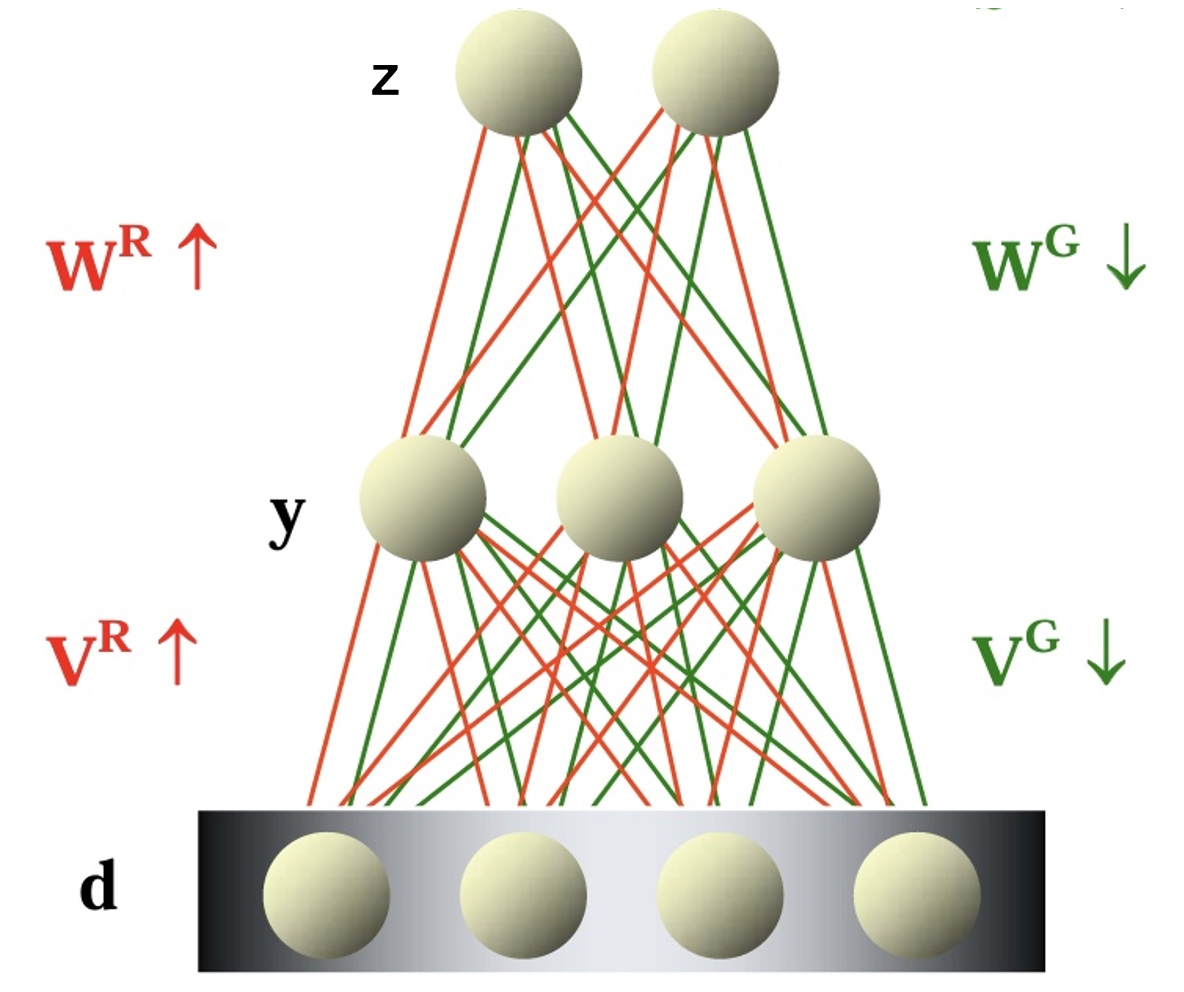

Adpated from the Figure in https://websites.nku.edu/~kirby/docs/HelmholtzTutorialKoeln.pdf

## A Diagram of the Helmholtz Machine

A diagram of the Helmholtz machine is shown above. There are two sets of weights: **top-down generative connection weights (green)** and **bottom-up recognition connection weights (red)**. Similar to Boltzmann machine, the sigmoid activation function is used at each layer in the network. Similar to the Boltzmann machine, the neurons in the Helmholtz machine are still taking binary values (because neural activities in the brain are binary) based on the sigmoid activation function. Therefore, the Helmholtz machine is also assumed to be in a positive temperature state (because neuron activations are probabilistic with the sigmoid activation function) and the temperature parameter $\beta$ (or $c_1$ in the figure shown below) in the sigmoid activation function is usually assumed to be 1 (fixed temperature) for simplicity.



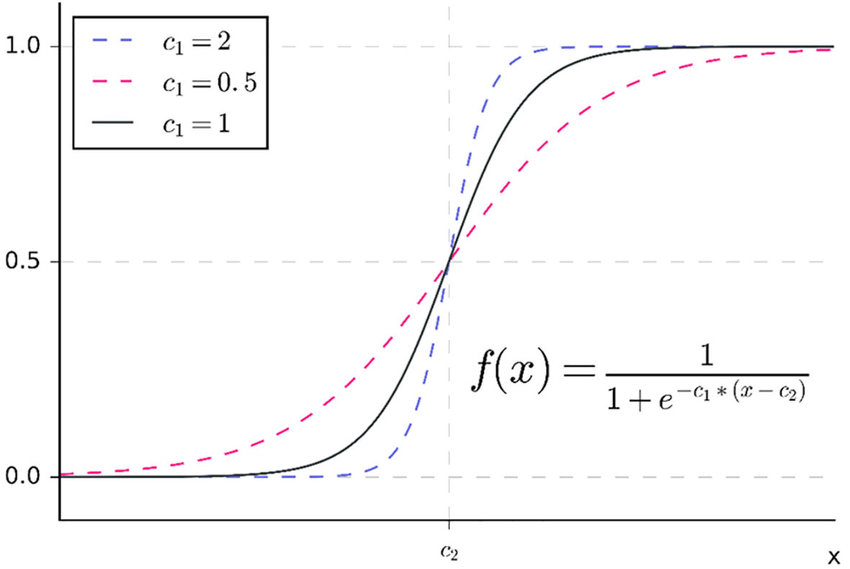

Temperature affect the shape of the sigmoid function.

Source: https://www.researchgate.net/figure/Basic-sigmoid-function-Note-A-Basic-sigmoid-function-with-two-parameters-c-1-and-c-2_fig2_327512672

## Top-Down Generation

The distribution of the latent representation in the final hidden layer is assumed to follow a sigmoid distribution $p_G(\mathbf{z}) = σ(b^G(\mathbf{z}))$ and $b^G(\mathbf{z})$ is a parameter learned during training.

The top-down generative connection weight matrices $W^G$ and $V^G$ are used to specify the generative distribution $p_G(\mathbf{z, y, d})$.

The Helmholtz machine will try to learn a $p_G(\mathbf{z, y, d})$ (which is the product of $p_G(\mathbf{z})$, $p_G(\mathbf{y} | \mathbf{z})$, and $p_G(\mathbf{d} | \mathbf{y})$) so that it can produce $p_G(\mathbf{d})$ that is as close to $p(\mathbf{d})$ as possible.

### Expressing directional probabilities using the neural network weights

We can get the directional probabilities from the neural network weights as follows, based on equations (1) and (2):

$$
p_G(\mathbf{z}) = \prod_k p_G(z_k)^{z_k} [1 - p_G(z_k)]^{1 - z_k} \quad \text{where} \quad p_G(z_k) \text{ is the prior distribution and } p_G(\mathbf{z}) = σ(b^G(\mathbf{z}))
$$

$$
p_G(\mathbf{y} | \mathbf{z}) = \prod_j p_G(y_j | \mathbf{z})^{y_j} [1 - p_G(y_j | \mathbf{z})]^{1 - y_j}
\quad \text{where} \quad p_G(y_j | \mathbf{z}) = \sigma \left( \sum_{k=1}^{L} W^G_{jk} z_k + W^G_{j, L+1} \right)
$$

$$
p_G(\mathbf{d} | \mathbf{y}) = \prod_i p_G(d_i | \mathbf{y})^{d_i} [1 - p_G(d_i | \mathbf{y})]^{1 - d_i}
\quad \text{where} \quad p_G(d_i | \mathbf{y}) = \sigma \left( \sum_{j=1}^{M} V^G_{ij} y_j + V^G_{i, M+1} \right)
$$

where $ \sigma $ is the **sigmoid function**:

$$
\sigma(u) = (1 + \exp^{-u})^{-1}.
$$

The latent variable $ \mathbf{z} $ is the **“cause”**. The $ \mathbf{z,y} $ (the state of all the hidden units) are the **“explanation”** of $ \mathbf{d} $.

Of course, the actual number of neurons in each layer is unrestricted and there are variants of Helmholtz machines with more layers, different activation functions, lateral connections, and so on. But for this tutorial, we will use the simple architecture depicted above.


## The Goal of Helmholtz Machine Learning

Now the goal of Helmholtz machine learning is to find a model $ G $ (that is, find $ p_G(\mathbf{z}) $, $ W^G $, and $ V^G $) that makes $ p_G(\mathbf{d}) $ as close to $ p(\mathbf{d}) $ as possible. When this happens, the machine will have made a generative model of the world based on the data. So we want to find a $ G $ that minimizes the function:

$$
\Phi(G) \equiv \text{KL} [ p(\mathbf{d}), p_G(\mathbf{d}) ]
$$

Where $KL$ represents Kullback-Leibler divergence (KL divergence). KL divergence is used to measure the difference between two probability distributions. According to the definition of KL divergence, we get:

$$
\Phi(G) \equiv \text{KL} [ p(\mathbf{d}), p_G(\mathbf{d}) ] = \sum_{\mathbf{d}} p(\mathbf{d}) \log \frac{p(\mathbf{d})}{p_G(\mathbf{d})}
= \sum_{\mathbf{d}} p(\mathbf{d}) \log p(\mathbf{d}) - \sum_{\mathbf{d}} p(\mathbf{d}) \log p_G(\mathbf{d}) \tag{5}
$$

where the first term $\sum_{\mathbf{d}} p(\mathbf{d}) \log p(\mathbf{d})$ does not depend on $ G $ and thus can be ignored in our optimization of $ G $.  

What's left is the second term $- \sum_{\mathbf{d}} p(\mathbf{d}) \log p_G(\mathbf{d})$. The term $-\log p_G(\mathbf{d})$ is called the **surprise** of the data because the value of it is 0 when there is no surprise $p_G(\mathbf{d}) = 1$ and there is a big positive surprise if $p_G(\mathbf{d}) → 0$ (i.e. the real world data is a very unlikely data pattern for the model to generate). Therefore, the second term is the expected **surprise** of the data for the generated model, weighted by the real-world probability of the data:

We define

$$
\Phi_0 (G) \equiv \langle -\log p_G (\mathbf{d}) \rangle = - \sum_{\mathbf{d}} p(\mathbf{d}) \log p_G(\mathbf{d}).
\tag{6}
$$

As we sample patterns in the real world, we keep track of how surprising it would be if the machine generated that pattern. This **accumulated surprise** as we sample will get smaller as the machine learns to model the world, as $ p_G(\mathbf{d}) $ moves closer to $ p(\mathbf{d}) $.

Therefore, now our optimization problem is to find a $ G $ that minimizes this **expected surprise** $ \Phi_0(G) $. As usual, we will still use a **gradient descent algorithm**. That means we will need to compute the gradients $ \nabla $ of $ \Phi_0(G) $ with respect to network weights. Since any gradient operator $ \nabla $ is linear, we will have:

$$
\nabla \Phi_0 = \sum_{\mathbf{d}} p(\mathbf{d}) \nabla [-\log p_G (\mathbf{d})].
\tag{7}
$$


In gradient descent optimization, we will make little changes to the weights proportional to $ \nabla \Phi_0 $. Since the gradient consists of a $ p(\mathbf{d}) $-weighted sum of the gradients of $ -\log p_G(\mathbf{d}) $, our algorithm can just sample a $ \mathbf{d} $ from the real-world $ p(\mathbf{d}) $ distribution, then add in an increment proportional to $ \nabla [-\log p_G(\mathbf{d})] $. As we keep adding these up, sampling according to $ p(\mathbf{d}) $, we get the same weighted sum as in equation (7). So finding the various gradients of $ -\log p_G(\mathbf{d}) $ is all we need to do to prepare a gradient descent algorithm to make $ p_G(\mathbf{d}) $ approach $ p(\mathbf{d}) $.

Therefore, we turn our attention to minimizing $ -\log p_G(\mathbf{d}) $, the **generative surprise**, and rearrange it to get an interesting new form:

$$
-\log p_G (\mathbf{d}) = -\log p_G (\mathbf{d}) \cdot 1
$$

$$
= -\log p_G (\mathbf{d}) \cdot \left[ \sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \right]
$$

$$
= -\sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log p_G (\mathbf{d})
$$

$$
= -\sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log \left[ \frac{p_G (\mathbf{z, y, d})}{p_G (\mathbf{z, y} | \mathbf{d})} \right]
$$

$$
= -\sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log p_G (\mathbf{z, y, d}) + \sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y} | \mathbf{d}) \tag{8}
$$

The reason for making this arrangement is we need to express the generative surprise in a form that is dependent on the model hidden units distribution $p_G(\mathbf{z, y} | \mathbf{d})$ so that we can know how to minimize generative surprise by changing the hidden units distribution.

However, the gradient of $-\log p_G (\mathbf{d})$ is difficult to compute even after we have made the above arrangement.

## Variational Upper Bound

In order to find an alternative way to minimize the generative surprise **($\Phi_0 (G)$)**, let us consider another random distribution $ p_R(\mathbf{z, y} | \mathbf{d}) $, which can be any arbitrary distribution for the moment. We do not need a full joint $ p_R(\mathbf{z, y, d}) $ in what follows. In particular, we do not need $ p_R(\mathbf{d}) $.

For a fixed data pattern $ \mathbf{d} $, compute the KL divergence of explanations from $ p_R $ to the generative distribution $ p_G $:

$$
\text{KL} [ p_R(\mathbf{z, y} | \mathbf{d}), p_G(\mathbf{z, y} | \mathbf{d}) ] \equiv \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log \frac{p_R(\mathbf{z, y} | \mathbf{d})}{p_G(\mathbf{z, y} | \mathbf{d})}
$$

$$
= \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y} | \mathbf{d})
$$

$$
= \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log \frac{p_G(\mathbf{z, y, d})}{p_G(\mathbf{d})}
$$

$$
= \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d}) + \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{d})
$$

$$
= \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d}) + \log p_G(\mathbf{d})
$$

Because KL divergence is always nonnegative, we have:

$$
\sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d}) + \log p_G(\mathbf{d}) \geq 0
$$

or

$$
- \log p_G(\mathbf{d}) \leq \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d})
$$

Define the **Variational Upper Bound** of the surprise $- \log p_G(\mathbf{d})$ as

$$
F^R_G(\mathbf{d}) = \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d}) \tag{9} \\ = \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y}|\mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{d}) \\ = \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y}|\mathbf{d}) - \log p_G(\mathbf{d}) \\ = -\log p_G(\mathbf{d}) + \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log \frac{p_R(\mathbf{z, y} | \mathbf{d})}{p_G(\mathbf{z, y} | \mathbf{d})} \\ = F_G(\mathbf{d}) + KL[p_R(\mathbf{z, y} | \mathbf{d}),p_G(\mathbf{z, y} | \mathbf{d})]
$$

Therefore, we have

$$
F^R_G(\mathbf{d}) = F_G(\mathbf{d}) + KL[p_R(\mathbf{z, y} | \mathbf{d}),p_G(\mathbf{z, y} | \mathbf{d})] \tag{10}
$$

Where

$F_G(\mathbf{d}) = -\log p_G(\mathbf{d})$

is the original thing that we want to minimize,

and

$KL[p_R(\mathbf{z, y} | \mathbf{d}),p_G(\mathbf{z, y} | \mathbf{d})] = \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log \frac{p_R(\mathbf{z, y} | \mathbf{d})}{p_G(\mathbf{z, y} | \mathbf{d})}$

is the difference between the variational upper bound and the original thing that we want to minimize.

**Then we can minimize the surprise $- \log p_G(\mathbf{d})$ by minimizing the variational upper bound of the surprise $F^R_G(\mathbf{d})$.**


## Bottom-Up Recognition

We would like to find a good $ p_R(\mathbf{z, y} | \mathbf{d}) $ so that the variational upper bound is close to the true value of $F_G(\mathbf{d})$, but how to find it?  

We can learn a good $ p_R(\mathbf{z, y} | \mathbf{d}) $ using bottom-up recognition to approach the variational upper bound of the generative surprise.

We call $ p_R(\mathbf{z, y} | \mathbf{d}) $ the **recognition** distribution, and assume it follows a causal chain in the opposite direction of the generative process:

$$
\mathbf{d} \to \mathbf{y} \to \mathbf{z}.
$$

That means that $\mathbf{d}$ and $\mathbf{z}$ are independent given $\mathbf{y}$ and we can factor:

$$
p_R(\mathbf{z, d} | \mathbf{y}) = p_R(\mathbf{z} | \mathbf{y}) p_R(\mathbf{d} | \mathbf{y}).
$$

and

$$
p_R(\mathbf{z} | \mathbf{y,d}) = p_R(\mathbf{z} | \mathbf{y})
$$

Therefore

$$
p_R(\mathbf{z, y} | \mathbf{d}) = p_R(\mathbf{z} | \mathbf{y,d}) p_R(\mathbf{y} | \mathbf{d}) = p_R(\mathbf{z} | \mathbf{y}) p_R(\mathbf{y} | \mathbf{d}) \tag{11}
$$

Let these two factors be determined by **bottom-up connections** in the Helmholtz machines, and call them the **recognition weights**, $ V^R $ and $ W^R $.  

Analogously to the equations for generation process, we have similiar equations for recognition (expressing probabilities using the neural network weights):

$$
p_R(\mathbf{z} | \mathbf{y}) = \prod_k p_R(z_k | \mathbf{y})^{z_k} [1 - p_R(z_k | \mathbf{y})]^{1 - z_k}
$$

$$
\text{where} \quad p_R(z_k | \mathbf{y}) = \sigma \left( \sum_{j=1}^{M} W^R_{kj} y_j + W^R_{k, M+1} \right)
$$

$$
p_R(\mathbf{y} | \mathbf{d}) = \prod_j p_R(y_j | \mathbf{d})^{y_j} [1 - p_R(y_j | \mathbf{d})]^{1 - y_j}
$$

$$
\text{where} \quad p_R(y_j | \mathbf{d}) = \sigma \left( \sum_{i=1}^{N} V^R_{ji} d_i + V^R_{j, N+1} \right)
$$

The pattern $ \mathbf{d} $ is the data **input**.  



## Training a Helmholtz Machine

A **Helmholtz machine** can learn the distribution of the real world data by minimizing the surprise $ F_G(\mathbf{d}) $.   

The idea is to use a **gradient descent** method to train the Helmholtz machine. However, calculation of gradients is complicated if we want to directly use the gradient of $ F_G(\mathbf{d}) $.  

Therefore, as we have shown above, we turn to minimize the variational upper bound $ F_G^R(\mathbf{d}) $, and this upper bound involves a separate **recognition distribution**.

Minimizing $ F_G^R(\mathbf{d}) $ simultaneously minimizes the **surprise** $ F_G(\mathbf{d}) $ and the **KL divergence** from $ p_R(\mathbf{z, y} | \mathbf{d}) $ to $ p_G(\mathbf{z, y} | \mathbf{d}) $.

Each training iteration of the Helholtz machine involves two phases, one updating the **generative weights** when it is receiving real world data inputs (Wake Phase) and another one updating the **recognition weights** when it is not receiving real world data inputs but instead generating artificial data using the model (Sleep Phase).  

That is, we **alternately** make small weight changes in **G** and in **R**.



### Overview of the Wake-Sleep Algorithm:
#### **Wake Phase**

In the first phase, called the **“wake”** phase, we **sample a true data pattern $ \mathbf{d} $ from the real world** and update the generation weights **$ b^G, W^G, V^G $** so as to **reduce the variational upper bound $ F_G^R(\mathbf{d}) $**.

Specifically, we make a small change in the **generation weights** to reduce the **variational upper bound** from equation (6):

$$
F_G^R(\mathbf{d}) = F_G(\mathbf{d}) + \text{KL}[p_R(\mathbf{z, y} | \mathbf{d}), p_G(\mathbf{z, y} | \mathbf{d})].
$$

There is **one free variable** here: $ \mathbf{d} $. We sample it from the **real-world** $ p(\mathbf{d}) $ (**not from the generated data distribution**), as our original goal was to minimize $ \langle F_G(\mathbf{d}) \rangle $ where the average is taken under the **real-world data distribution**.


#### **Sleep Phase**

In the second phase, called the **“sleep”** phase, we **sample a latent representation $ \mathbf{z} $** from the final hidden layer and **update the recognition weights $ W^R, V^R $** so as to **reduce a slightly different variational upper bound $ \tilde{F_G^R}(\mathbf{d}) $**.

Specifically, we make a small change in the **recognition weights** to reduce not $ F_G^R(\mathbf{d}) $ but a slightly different quantity that approximates it to make it possible to implement it using an artificial neural network:

$$
\tilde{F_G^R}(\mathbf{d}) = F_G(\mathbf{d}) + \text{KL}[p_G(\mathbf{z, y} | \mathbf{d}), p_R(\mathbf{z, y} | \mathbf{d})].
$$

It is a slightly different quantity because $\text{KL}(p_a,p_b) \neq \text{KL}(p_b,p_a)$ though the difference between them is small.


### Derivations of the weight updating rule for the Wake Phase (Optional)  

we now evaluate the derivatives of $F^R_G(\mathbf{d})$ to derive the learning algorithm.

According to equation (9) that we have derived above:

$$
F^R_G(\mathbf{d}) = \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d})
$$

The first term is not depedent on model weights, so it can be regarded as a constant when calculating the gradient with respect to weights:

$$
\nabla_G F^R_G(\mathbf{d}) = \nabla_G (\text{Constant}) - \nabla_G \left[\sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \log p_G(\mathbf{z, y, d})\right] \\ = - \sum_{\mathbf{z, y}} p_R(\mathbf{z, y} | \mathbf{d}) \nabla_G \left[\log p_G(\mathbf{z, y, d})\right] \\ = \langle -\nabla_G \log p_G(\mathbf{z, y, d}) \rangle_R \tag{12}
\quad
$$

Then we unpack the generative distribution:

$$
-\nabla_G \log p_G(\mathbf{z, y, d}) = - \nabla_G \log[p_G(\mathbf{z})p_G(\mathbf{y}|\mathbf{z})p_G(\mathbf{d}|\mathbf{y})] = -\nabla_G \log p_G(\mathbf{z}) - \nabla_G \log p_G(\mathbf{y}|\mathbf{z}) -\nabla_G \log p_G(\mathbf{d}|\mathbf{y})
$$

Then we express the negative log probabilities in terms of weights and states in the neural network:

$$
-\log p_G(\mathbf{z}) = -\log \prod_k \xi_k^{z_k} (1 - \xi_k)^{1 - z_k}
$$

$$
= -\sum_k z_k \log \xi_k - \sum_k (1 - z_k) \log (1 - \xi_k)
$$

$$
\text{where} \quad \xi_k \equiv p_G(z_k) \quad \text{and} \quad p_G(\mathbf{z}) = σ(b^G(\mathbf{z}))
$$

---

$$
-\log p_G(\mathbf{y} | \mathbf{z}) = -\log \prod_j \psi_j^{y_j} (1 - \psi_j)^{1 - y_j}
$$

$$
= -\sum_j y_j \log \psi_j - \sum_j (1 - y_j) \log (1 - \psi_j)
$$

$$
\text{where} \quad \psi_j \equiv \sigma \left( \sum_{k=1}^{L} W^G_{jk} z_k + W^G_{j, L+1} \right)
$$

---

$$
-\log p_G(\mathbf{d} | \mathbf{y}) = - \log \prod_i \delta_i^{d_i} (1 - \delta_i)^{1 - d_i}
$$

$$
= -\sum_i d_i \log \delta_i - \sum_i (1 - d_i) \log (1 - \delta_i)
$$

$$
\text{where} \quad \delta_i \equiv \sigma \left( \sum_{j=1}^{M} V^G_{ij} y_j + V^G_{i, M+1} \right)
$$

---

Calculate the gradient of the above negative log probabilities with respect to weights:

$$
- \frac{\partial}{\partial b^G_{k}} \log p_G(\mathbf{z}) = - (z_k - \xi_k)
$$

$$
- \frac{\partial}{\partial b^G_{k}} \log p_G(\mathbf{y} | \mathbf{z}) = 0
$$

$$
-\frac{\partial}{\partial b^G_{k}} \log p_G(\mathbf{d} | \mathbf{y}) = 0
$$



---

$$
- \frac{\partial}{\partial W^G_{jk}} \log p_G(\mathbf{z}) = 0
$$

$$
- \frac{\partial}{\partial W^G_{jk}} \log p_G(\mathbf{y} | \mathbf{z}) =
\begin{cases}
-(y_j - \psi_j) z_k, & k = 1,2, \dots, L \\
-(y_j - \psi_j), & k = L+1
\end{cases}
$$

$$
-\frac{\partial}{\partial W^G_{jk}} \log p_G(\mathbf{d} | \mathbf{y}) = 0
$$

---

$$
-\frac{\partial}{\partial V^G_{ij}} \log p_G(\mathbf{z}) = 0
$$

$$
-\frac{\partial}{\partial V^G_{ij}} \log p_G(\mathbf{y} | \mathbf{z}) = 0
$$

$$
-\frac{\partial}{\partial V^G_{ij}} \log p_G(\mathbf{d} | \mathbf{y}) =
\begin{cases}
-(d_i - \delta_i) y_j, & j = 1,2, \dots, M \\
-(d_i - \delta_i), & j = M+1
\end{cases}
$$

---

Therefore, in order to minimize the variational upper bound, we should update weights in the opposite direction of the gradients:

$$
b^G(\mathbf{z}) = b^G(\mathbf{z}) + \eta (\mathbf{z} - \boldsymbol{\xi})
$$

$$
p_G(\mathbf{z}) = σ(b^G(\mathbf{z}))
$$

$$
\mathbf{W}^G = \mathbf{W}^G + \eta (\mathbf{y} - \boldsymbol{\psi}) \begin{bmatrix} \mathbf{z} | 1 \end{bmatrix}^T
$$

$$
\mathbf{V}^G = \mathbf{V}^G + \eta (\mathbf{d} - \boldsymbol{\delta}) \begin{bmatrix} \mathbf{y} | 1 \end{bmatrix}^T
$$

where $ \eta $ is the learning rate, $\begin{bmatrix} \mathbf{z} | 1 \end{bmatrix}$ and $\begin{bmatrix} \mathbf{y} | 1 \end{bmatrix}$ mean adding values of one to the vectors for the bias term.





### Derivations of the weight updating rule for the Sleep Phase (Optional)

According to what we have explained above, we need to minimize the following expression:

$$
\tilde{F_G^R}(\mathbf{d}) = F_G(\mathbf{d}) + \text{KL}[p_G(\mathbf{z, y} | \mathbf{d}), p_R(\mathbf{z, y} | \mathbf{d})].
$$

The first term $F_G(\mathbf{d})$ is independent of recognition weights, so it can be regarded as a constant when calculating gradients.

$$
\nabla_R \tilde{F_G^R}(\mathbf{d}) = \nabla_R (\text{Constant}) + \nabla_R \text{KL}[p_G(\mathbf{z, y} | \mathbf{d}), p_R(\mathbf{z, y} | \mathbf{d})] \\ = \nabla_R \left[\sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log \frac{p_G(\mathbf{z, y} | \mathbf{d})}{p_R(\mathbf{z, y} | \mathbf{d})}\right] \\ = -\nabla_R \sum_{\mathbf{z, y}} p_G(\mathbf{z, y} | \mathbf{d}) \log p_R(\mathbf{z, y} | \mathbf{d}) \\ = -\langle \nabla_R \log p_R(\mathbf{z, y} | \mathbf{d}) \rangle_G \tag{13}
$$

Then we unpack $p_R(\mathbf{z, y} | \mathbf{d})$ according to equation (11)

$$
-\nabla_R \log p_R(\mathbf{z, y} | \mathbf{d}) = -\nabla_R \log p_R(\mathbf{y} | \mathbf{d}) - \nabla_R \log p_R(\mathbf{z} | \mathbf{y})
$$

Then we express the negative log probabilities in terms of weights and states in the neural network:

$$
-\log p_R(\mathbf{z} | \mathbf{y}) = -\log \prod_k \xi_k^{z_k} (1 - \xi_k)^{1 - z_k}
$$

$$
= -\sum_k z_k \log \xi_k - \sum_k (1 - z_k) \log (1 - \xi_k)
$$

$$
\text{where} \quad \xi_k \equiv \sigma \left( \sum_{j=1}^{M} W^R_{kj} y_j + W^R_{k, M+1} \right)
$$

---

$$
-\log p_R(\mathbf{y} | \mathbf{d}) = -\log \prod_j \psi_j^{y_j} (1 - \psi_j)^{1 - y_j}
$$

$$
= -\sum_j y_j \log \psi_j - \sum_j (1 - y_j) \log (1 - \psi_j)
$$

$$
\text{where} \quad \psi_j \equiv \sigma \left( \sum_{i=1}^{N} V^R_{ji} d_i + V^R_{j, N+1} \right)
$$

Calculate the gradient of the above negative log probabilities with respect to weights:

$$
-\frac{\partial}{\partial W^R_{kj}} \log p_R(\mathbf{z} | \mathbf{y}) =
\begin{cases}
-(z_k - \xi_k) z_j, & j = 1,2, \dots, M \\
-(z_k - \xi_k), & j = M+1
\end{cases}
$$

$$
-\frac{\partial}{\partial W^R_{kj}} \log p_R(\mathbf{y} | \mathbf{d}) = 0
$$

---

$$
-\frac{\partial}{\partial V^R_{ji}} \log p_R(\mathbf{x} | \mathbf{y}) = 0
$$

$$
-\frac{\partial}{\partial V^R_{ji}} \log p_R(\mathbf{y} | \mathbf{d}) =
\begin{cases}
-(y_j - \psi_j) d_i, & i = 1,2, \dots, N \\
-(y_j - \psi_j), & i = N+1
\end{cases}
$$

Therefore, in order to minimize the variational upper bound, we should update weights in the opposite direction of the gradients:

$$
\mathbf{W}^R = \mathbf{W}^R + \eta (\mathbf{z} - \boldsymbol{\xi}) \begin{bmatrix} \mathbf{y} | 1 \end{bmatrix}^T
$$

$$
\mathbf{V}^R = \mathbf{V}^R + \eta (\mathbf{y} - \boldsymbol{\psi}) \begin{bmatrix} \mathbf{d} | 1 \end{bmatrix}^T
$$

where $ \eta $ is the learning rate, $\begin{bmatrix} \mathbf{d} | 1 \end{bmatrix}$ and $\begin{bmatrix} \mathbf{y} | 1 \end{bmatrix}$ mean adding values of one to the vectors for the bias term.


### Summarizing the Algorithm

### Initialization (set to 0 or some small random weights)

$$
V^G, W^G = 0, b^G = 0   
$$

$$
V^R, W^R = 0
$$

**repeat**  

- *wake phase* to update $ V^G, W^G, b^G$,   
- *sleep phase* to update $ V^R, W^R $  

**until**  

$$
\text{KL}[p(\mathbf{d}), p_G(\mathbf{d})] \text{ is sufficiently close to 0.}
$$

---

## **Wake Phase**
```cpp
// Experience reality!
d = getSampleFromWorld()

// Pass sensory data up through recognition network
y = SAMPLE( σ (V^R [d | 1]^T ) )
z = SAMPLE( σ (W^R [y | 1]^T ) )

// Pass back down through generation network, saving computed probabilities
ξ = σ (b^G )
ψ = σ (W^G [z | 1]^T )
δ = σ (V^G [y | 1]^T )

// Adjust generative weights by delta rule
b^G  += η (z - ξ)
W^G  += η (y - ψ) [z | 1]^T
V^G  += η (d - δ) [y | 1]^T
```

---

## **Sleep Phase**

```cpp
// Initiate a dream!
z = SAMPLE( p_G(z) );

// Pass dream signal down through generation network
y = SAMPLE( sigma(W^G * (z | 1).T) );
d = SAMPLE( sigma(V^G * (y | 1).T) );

// Pass back up through recognition network, saving computed probabilities
ψ = σ(V^R * (d | 1).T);
ξ = σ(W^R * (y | 1).T);

// Adjust recognition weights by delta rule
VR  += η * (y - psi) * (d | 1).T;
WR  += η * (z - xi) * (y | 1).T;
```



---

To summarize, given a **generative distribution** $ p_G(z,y,d) $ and a **recognition distribution** $ p_R(z,y \mid d) $ with the following **causal structure**:

$$
z \overset{G, R}{\longleftrightarrow} y \overset{G, R}{\longleftrightarrow} d
$$

We **alternately maximize** their expected *log-likelihoods*, where the expectation is taken against the *other* distribution:

$$
\langle \log p_G(Z,Y,D) \rangle_R \quad \text{and} \quad \langle \log p_R(Z,Y|D) \rangle_G
$$


# Question #1

1. Which network's weights are updated during the wake phase? Which network's weights are updated during the sleep phase?

2. During the wake phase, the Helmholtz machine draws samples from which distribution? During the sleep phase, the Helmholtz machine draws samples from which distribution?

3. The goal of the sleep phase is to minimize the gap between which two things?

1. During wake phase, generation network's weights are updated, and during the sleep phase, recognition network's weights are updated.
2. During the wake phase, samples are drawn from the real world data distribution p(d), and during the sleep phase, samples are drawn from the generative model distribution pG(z).
3. To minimize gap between recognition distribution and the generative distribution, specifically to make pR(z,y∣d) closer to pG(z,y∣d)

## Implement a Helmholtz Machine

### Set Up the World

This is a variant of one example used in the Hinton-Dayan's orignial Science paper about the Helmholtz machine.  The world consists of 3×3 images of vertical and horizontal bars.  Vertical bars occur with twice the probability of horizontal bars, but within each category (horizontal or vertical) each of the possibilities occurs with the same probability.

The state of each input unit has two possible values and there are 9 input units $\mathbf{d} ∈ \{0,1\}^9$ , so there are 512 possible patterns. To get the distribution above, we assign probabilities as follows:  

high frequency:  $p(\mathbf{d}) = 2/18 =  0.111$ for each vertical bar pattern $\mathbf{d}$

low frequency:  $p(\mathbf{d}) = 1/18 =  0.056$ for each horizontal bar pattern $\mathbf{d}$

with $p(\mathbf{d}) = 0$ for the other 500 patterns.

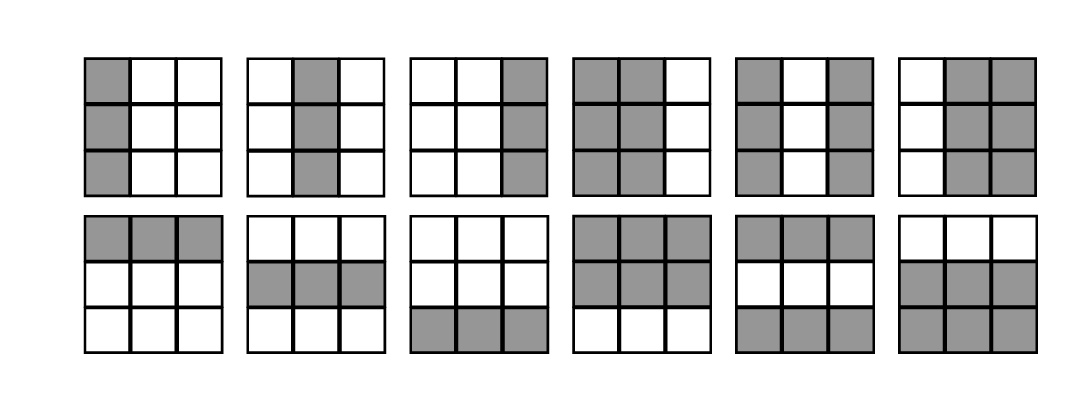

The Helmholtz machine in its initial state will generate all 512 patterns uniformly, so that

$$
p_G(\mathbf{d}) = \frac{1}{512} \approx 0.002
$$

for every pattern $\mathbf{d} \in \{0,1\}^9$. As the learning algorithm proceeds, we expect $p_G(\mathbf{d})$ to approach the given $p(\mathbf{d})$.

We simulate a Helmholtz machine with 1 latent variable unit in $\mathbf{x}$ (so $\mathbf{x} \in \{0,1\}^1$ and it is labeled as $\mathbf{z}$ in the above theory section) and 6 hidden units in $\mathbf{y}$ ($\mathbf{y} \in \{0,1\}^6$).

With learning rates set to $\varepsilon = 0.01$ for the top $W$ layer, and $\varepsilon = 0.15$ for the bottom $V$ layer, we run the algorithm for 60000 iterations. We then stop to evaluate the generative distribution, taking 100000 samples to estimate probabilities.


In [3]:

# -----------------------------
# 1. Define the 3×3 bars world
# -----------------------------
def make_3x3_binary(pattern):
    """
    Convert a list of row-strings like ['XXX','...','...']
    into a 9D binary vector (row-major). 'X'=1, '.'=0.
    """
    vec = []
    for row in pattern:
        for c in row:
            vec.append(1 if c == 'X' else 0)
    return np.array(vec)

# Vertical bars (any combination of columns)
vertical_bar_patterns = [
    make_3x3_binary(['X..','X..','X..']),  # left column
    make_3x3_binary(['.X.','.X.','.X.']),  # center column
    make_3x3_binary(['..X','..X','..X']),  # right column
    make_3x3_binary(['XX.','XX.','XX.']),  # left+center
    make_3x3_binary(['.XX','.XX','.XX']),  # center+right
    make_3x3_binary(['X.X','X.X','X.X'])   # left + right
]

# Horizontal bars (any combination of rows)
horizontal_bar_patterns = [
    make_3x3_binary(['XXX','...','...']),  # top row
    make_3x3_binary(['...','XXX','...']),  # middle row
    make_3x3_binary(['...','...','XXX']),  # bottom row
    make_3x3_binary(['XXX','XXX','...']),  # top+middle
    make_3x3_binary(['...','XXX','XXX']),  # middle+bottom
    make_3x3_binary(['XXX','...','XXX'])   # top + bottom
]

# Probabilities: vertical patterns 2/18 each, horizontal patterns 1/18
p_vert = 2.0 / 18.0
p_horz = 1.0 / 18.0

all_bar_patterns = vertical_bar_patterns + horizontal_bar_patterns
all_bar_probs = [p_vert]*len(vertical_bar_patterns) + [p_horz]*len(horizontal_bar_patterns)
all_bar_patterns = np.array(all_bar_patterns)
all_bar_probs = np.array(all_bar_probs)

assert abs(all_bar_probs.sum() - 1.0) < 1e-9, "Probabilities do not sum to 1!"

def sample_data(batch_size=1):
    """Sample 'batch_size' data vectors from the 3×3 bars distribution."""
    idx = np.random.choice(len(all_bar_patterns), size=batch_size, p=all_bar_probs)
    return all_bar_patterns[idx]

# Sigmoid helper
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))



### Set Up the Helmholtz Machine

# Coding Exercise #1 #2 #3 #4

Please note that in the following code:  

The latent representation is represented using X, not Z.

The data is represented using V, not D.

In [4]:

# ------------------------------------
# 2. Helmholtz machine
# ------------------------------------
class HelmholtzMachine:
    def __init__(self, n_visible=9, n_hidden=6, lr_top=0.01, lr_bottom=0.15, seed=0):
        """
        n_visible: dimension of visible layer (9 for 3×3)
        n_hidden:  dimension of hidden layer (6 in example)
        lr_top:    learning rate for top-level generative weights
        lr_bottom: learning rate for bottom-level generative & recognition weights
        """
        rs = np.random.RandomState(seed)
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.lr_top = lr_top
        self.lr_bottom = lr_bottom

        # GENERATIVE PARAMETERS
        # p(X=1) has single bias (the parameter for generating the sigmoid probabilities for the latent variable X)
        self.b_x_g = 0.0

        # p(Y|X): (n_hidden,1) weights + (n_hidden,) bias
        self.W_yx_g = rs.normal(0, 0.01, (n_hidden, 1))
        self.b_y_g  = rs.normal(0, 0.01, (n_hidden,))
        # p(V|Y): (n_visible, n_hidden) weights + (n_visible,) bias
        self.W_vy_g = rs.normal(0, 0.01, (n_visible, n_hidden))
        self.b_v_g  = rs.normal(0, 0.01, (n_visible,))

        # RECOGNITION PARAMETERS
        # q(Y|V): (n_hidden, n_visible) + (n_hidden,) bias
        self.b_y_r  = rs.normal(0, 0.01, (n_hidden,))
        self.W_yv_r = rs.normal(0, 0.01, (n_hidden, n_visible))
        # q(X|Y): (1, n_hidden) + single bias
        self.b_x_r  = 0.0
        self.W_xy_r = rs.normal(0, 0.01, (1, n_hidden))

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #1")
#############################################################################

    # --- Generative model: p(X), p(Y|X), p(V|Y) ---
    def pX(self):
        """Scalar p(X=1)."""
        return sigmoid(self.b_x_g) # hint: ???(self.b_x_g) where ??? is an activation function

    def sample_X_from_p(self, batch_size):
        """Sample X ~ Bernoulli(pX). X will be shape (batch_size,1)."""
        px = self.pX()  # scalar
        return (np.random.rand(batch_size,1) < px).astype(float)

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line#
# raise NotImplementedError("Coding Exercise #2")
#############################################################################

    def pY_given_X(self, X):
        """
        X shape: (batch_size,1).
        Weight matrix shape: (n_hidden,1), so Weight matrix's transpose is (1,n_hidden).

        """
        logits = X @ self.W_yx_g.T                # (batch_size,n_hidden)
        logits += self.b_y_g               # add the bias term
        return sigmoid(logits)                  # same shape

    def sample_Y_given_X(self, X):
        py = self.pY_given_X(X)
        return (np.random.rand(*py.shape) < py).astype(float)

    def pV_given_Y(self, Y):
        """
        Y shape: (batch_size,n_hidden).
        W_vy_g shape: (n_visible,n_hidden), so W_vy_g.T is (n_hidden,n_visible).
        (Y @ W_vy_g.T) => (batch_size,n_visible).
        """
        logits = Y @ self.W_vy_g.T
        logits += self.b_v_g
        return sigmoid(logits)

    def sample_V_given_Y(self, Y):
        pv = self.pV_given_Y(Y)
        return (np.random.rand(*pv.shape) < pv).astype(float)

    # --- Recognition model: q(Y|V), q(X|Y) ---
    def qY_given_V(self, V):
        """
        V shape: (batch_size, n_visible).
        W_yv_r shape: (n_hidden, n_visible),
        (V @ W_yv_r.T) => (batch_size, n_hidden).
        """
        logits = V @ self.W_yv_r.T
        logits += self.b_y_r
        return sigmoid(logits)

    def sample_Y_given_V(self, V):
        qy = self.qY_given_V(V)
        return (np.random.rand(*qy.shape) < qy).astype(float)

    def qX_given_Y(self, Y):
        """
        Y shape: (batch_size, n_hidden).
        W_xy_r shape: (1,n_hidden),
        (Y @ W_xy_r.T) => (batch_size,1).
        """
        logits = Y @ self.W_xy_r.T
        logits += self.b_x_r
        return sigmoid(logits)

    def sample_X_given_Y(self, Y):
        qx = self.qX_given_Y(Y)
        return (np.random.rand(*qx.shape) < qx).astype(float)

    # --- Wake–sleep updates ---
    def wake_phase(self, V_batch):
        """
        Wake phase:
          1) From real data V_batch, sample Y ~ q(Y|V), X ~ q(X|Y).
          2) Update the generative parameters p(V|Y), p(Y|X), p(X).
        """
        batch_size = V_batch.shape[0]

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #3")
#############################################################################

        # Recognize from real data
        Y_samp = self.sample_Y_given_V(V_batch)       # (batch_size,n_hidden)
        X_samp = self.sample_X_given_Y(Y_samp)    # (batch_size,1)


        # Update p(V|Y)
        pV = self.pV_given_Y(Y_samp)              # (batch_size,n_visible)
        diffV = V_batch - pV
        for j in range(self.n_visible):
            self.b_v_g[j] += self.lr_bottom * diffV[:, j].mean()
            for h in range(self.n_hidden):
                self.W_vy_g[j,h] += self.lr_bottom * np.mean(diffV[:,j] * Y_samp[:,h])

        # Update p(Y|X)
        pY = self.pY_given_X(X_samp)              # (batch_size,n_hidden)
        diffY = Y_samp - pY
        for h in range(self.n_hidden):
            self.b_y_g[h] += self.lr_top * diffY[:,h].mean()
            self.W_yx_g[h,0] += self.lr_top * np.mean(diffY[:,h] * X_samp[:,0])

        # Update p(X)
        pX = self.pX()  # scalar
        diffX = X_samp[:,0] - pX
        self.b_x_g += self.lr_top * diffX.mean()

    def sleep_phase(self, batch_size):
        """
        Sleep phase:
          1) Sample X, Y, V from the generative model.
          2) Update the recognition parameters q(Y|V), q(X|Y).
        """

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #4")
#############################################################################


        # Sample from generative data
        X_gen = self.sample_X_from_p(batch_size)                             # (batch_size,1)
        Y_gen = self.sample_Y_given_X(X_gen)      # (batch_size,n_hidden)
        V_gen = self.sample_V_given_Y(Y_gen)      # (batch_size,n_visible)

        # Recognition model tries to match these "fantasy" samples
        qY = self.qY_given_V(V_gen)               # (batch_size,n_hidden)
        diffY = Y_gen - qY
        for h in range(self.n_hidden):
            self.b_y_r[h] += self.lr_bottom * diffY[:,h].mean()
            for j in range(self.n_visible):
                self.W_yv_r[h,j] += self.lr_bottom * np.mean(diffY[:,h] * V_gen[:,j])

        qX = self.qX_given_Y(Y_gen)               # (batch_size,1)
        diffX = X_gen[:,0] - qX[:,0]
        self.b_x_r += self.lr_bottom * diffX.mean()
        for h in range(self.n_hidden):
            self.W_xy_r[0,h] += self.lr_bottom * np.mean(diffX * Y_gen[:,h])

    def train(self, n_iterations=60000, batch_size=1):
        for it in range(n_iterations):
            # Wake phase on real data
            V_batch = sample_data(batch_size=batch_size)
            self.wake_phase(V_batch)

            # Sleep phase on generative samples
            self.sleep_phase(batch_size)

            if (it+1) % 10000 == 0:
                print(f"Iteration {it+1} / {n_iterations}")

    def sample_from_model(self, n_samples=100000):
        """
        Draw n_samples from p(X,Y,V) by sampling top-down,
        then return the visible states V.
        """
        X_samp = self.sample_X_from_p(n_samples)
        Y_samp = self.sample_Y_given_X(X_samp)
        V_samp = self.sample_V_given_Y(Y_samp)
        return V_samp

### Train the machine

In [5]:

# -----------------------------
# 3. Train a Helholtz Machine
# -----------------------------

# Instantiate the Helmholtz machine

hm = HelmholtzMachine(
    n_visible=9,
    n_hidden=6,
    lr_top=0.01,
    lr_bottom=0.15,
    seed=0
)

# Train for 60,000 iterations
hm.train(n_iterations=60000, batch_size=1)

# After training, estimate the learned pG(d) by sampling from the model
n_gen_samples = 100000
V_samples = hm.sample_from_model(n_samples=n_gen_samples)

# Convert each 9-dim sample to a tuple so we can count frequencies
counts = Counter(tuple(v.astype(int)) for v in V_samples)


Iteration 10000 / 60000
Iteration 20000 / 60000
Iteration 30000 / 60000
Iteration 40000 / 60000
Iteration 50000 / 60000
Iteration 60000 / 60000


### Visualize Results

In [6]:

# -----------------------------
# 4. Visualize and Compare the true data distribution and the generated data distribution
# -----------------------------

world_dict = {}
for pattern, prob in zip(all_bar_patterns, all_bar_probs):
    # Convert pattern (length-9 array) to a tuple
    pat_tuple = tuple(pattern)
    world_dict[pat_tuple] = prob

from collections import Counter

n_gen_samples = 100000
V_samples = hm.sample_from_model(n_samples=n_gen_samples)
counts = Counter(tuple(v.astype(int)) for v in V_samples)

# Convert counts to probabilities
learned_dict = {}
for pat, c in counts.items():
    learned_dict[pat] = c / n_gen_samples


# Sort the 12 “bar” patterns into “vertical” vs. “horizontal”
vert_patterns = set(tuple(p) for p in vertical_bar_patterns)
horz_patterns = set(tuple(p) for p in horizontal_bar_patterns)

# Print a header
print("{:30s}  {:>8s}  {:>8s}".format("Pattern d", "World p(d)", "Model pG(d)"))
print("-"*60)

expected_pattern_total_probability = 0

# For each pattern in the vertical or horizontal sets
for p in vert_patterns:
    wprob = world_dict.get(p, 0.0)
    gprob = learned_dict.get(p, 0.0)
    expected_pattern_total_probability += gprob
    print("{:30s}  {:8.4f}  {:8.4f}".format(str(p), wprob, gprob))


# Print a separator line
print("-"*60)

for p in horz_patterns:
    wprob = world_dict.get(p, 0.0)
    gprob = learned_dict.get(p, 0.0)
    expected_pattern_total_probability += gprob
    print("{:30s}  {:8.4f}  {:8.4f}".format(str(p), wprob, gprob))

print("The expected_pattern_total_probability is", expected_pattern_total_probability)

# Then find any other patterns that the model generated with probability >= 0.001
others = []
for pat, prob in learned_dict.items():
    if (pat not in vert_patterns) and (pat not in horz_patterns) and prob >= 0.001:
        others.append(pat)

if others:
    print("-"*60)
    print("Other generated patterns (pG(d) >= 0.001):")
    for p in others:
        wprob = world_dict.get(p, 0.0)  # probably zero
        gprob = learned_dict[p]
        print("{:30s}  {:8.4f}  {:8.4f}".format(str(p), wprob, gprob))



Pattern d                       World p(d)  Model pG(d)
------------------------------------------------------------
(np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1))    0.1111    0.1176
(np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0))    0.1111    0.0734
(np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0))    0.1111    0.1131
(np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0))    0.1111    0.1297
(np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1))    0.1111    0.0689
(np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1))    0.1111    0.1195
-------------------------------------------------------

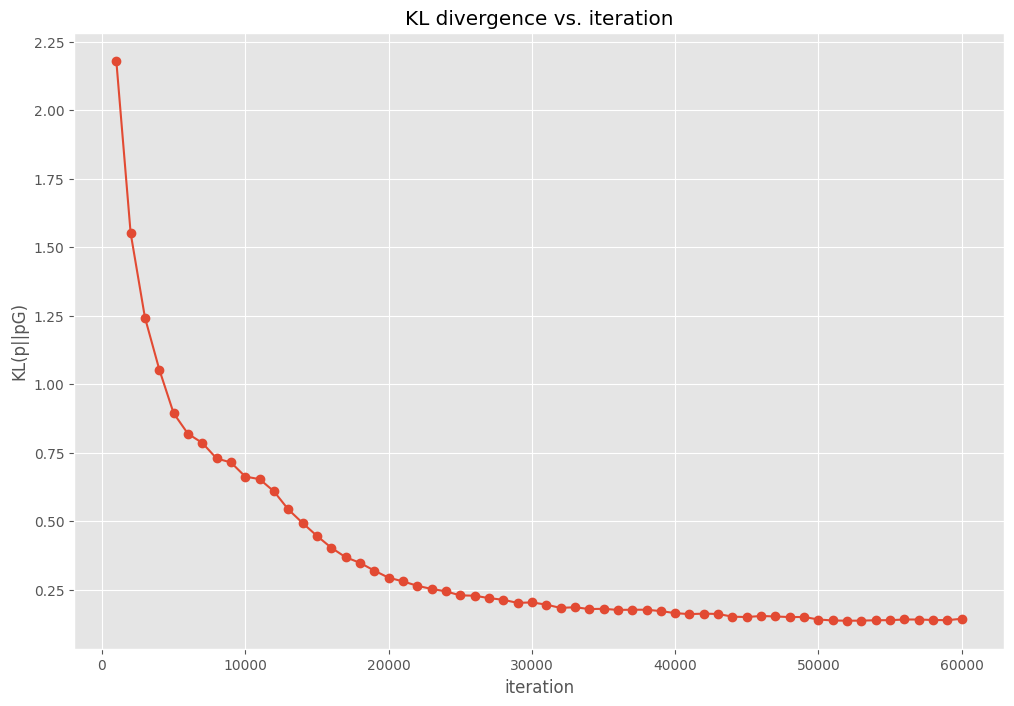

In [7]:

# -----------------------------
# 4. Visualize KL Divergence v.s. Iteration
# -----------------------------

def compute_KL(p_dict, pG_dict):
    """
    p_dict:  dictionary of true distribution, for the 12 bar patterns
    pG_dict: dictionary of model distribution for the same patterns
    returns: KL divergence sum_{d} p(d)*log[p(d)/pG(d)]
    For patterns d with pG(d)=0, we define log[p(d)/0] = +infinity, so treat carefully.
    """
    kl = 0.0
    for d, pd in p_dict.items():
        if pd > 0:
            pg = pG_dict.get(d, 0.0)
            if pg > 0.0:
                kl += pd * math.log(pd / pg)
            else:
                # if pg=0 but pd>0 => infinite KL
                kl += float('inf')
    return kl

n_iterations = 60000
KL_values = []
iter_list = []

hm = HelmholtzMachine(
        n_visible=9,
        n_hidden=6,
        lr_top=0.01,
        lr_bottom=0.15,
        seed=0
    )

for it in range(n_iterations):
    hm.wake_phase(sample_data(batch_size=1))
    hm.sleep_phase(batch_size=1)

    # Suppose we measure KL every 1000 steps
    if (it+1) % 1000 == 0:
        # estimate pG by sampling from model
        V_samples = hm.sample_from_model(100000)
        counts = Counter(tuple(v.astype(int)) for v in V_samples)
        # convert to dictionary
        pG_dict = {pat : c/100000.0 for pat, c in counts.items()}

        # compute KL wrt world_dict
        kl_val = compute_KL(world_dict, pG_dict)
        KL_values.append(kl_val)
        iter_list.append(it+1)

# Then plot using matplotlib


plt.figure()
plt.plot(iter_list, KL_values, marker='o', linestyle='-')
plt.xlabel("iteration")
plt.ylabel("KL(p||pG)")
plt.title("KL divergence vs. iteration")
plt.show()


## Comparison between Boltzmann machine and Helmholtz machine

| Feature | **Boltzmann Machine** | **Helmholtz Machine** |
|---------|----------------------|----------------------|
| **Network** | One network with symmetric weights | Two directed networks: a generation network and a recognition network|
| **Inference** | Requires slow MCMC sampling | Uses a recognition network for fast inference |
| **Training** | Uses contrastive divergence (expensive) | Uses wake-sleep algorithm (more efficient) |
| **Scalability** | Hard to train deep networks | Easier extends to deep models |


The **Helmholtz Machine** was introduced **to improve training efficiency, inference speed, and scalability** compared to the **Boltzmann Machine**. By introducing an **explicit recognition network**, it enables **faster and more structured learning**, paving the way for modern approaches like **Variational Autoencoders (VAEs)**.


# Variational Autoencoder

In [8]:
# @title Install dependencies
# @markdown #### Please ignore *errors* and/or *warnings* during installation.
!pip install pytorch-pretrained-biggan --quiet
!pip install Pillow libsixel-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:

# Imports
import torch
import random

import numpy as np
import matplotlib.pylab as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

from pytorch_pretrained_biggan import one_hot_from_names

from tqdm.notebook import tqdm, trange



In [10]:
# @title Set random seed

# @markdown Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [11]:
# @title Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# Inform the user if the notebook uses GPU or CPU.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

SEED = 0
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 0 has been set.
GPU is enabled in this notebook.


In [12]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, HBox, Layout, VBox
from ipywidgets import interactive_output, Dropdown

%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [13]:
# @title Helper functions


def image_moments(image_batches, n_batches=None):
  """
  Compute mean and covariance of all pixels
  from batches of images

  Args:
    Image_batches: tuple
      Image batches
    n_batches: int
      Number of Batch size

  Returns:
    m1: float
      Mean of all pixels
    cov: float
      Covariance of all pixels
  """
  m1, m2 = torch.zeros((), device=DEVICE), torch.zeros((), device=DEVICE)
  n = 0
  for im in tqdm(image_batches, total=n_batches, leave=False,
                 desc='Computing pixel mean and covariance...'):
    im = im.to(DEVICE)
    b = im.size()[0]
    im = im.view(b, -1)
    m1 = m1 + im.sum(dim=0)
    m2 = m2 + (im.view(b,-1,1) * im.view(b,1,-1)).sum(dim=0)
    n += b
  m1, m2 = m1/n, m2/n
  cov = m2 - m1.view(-1,1)*m1.view(1,-1)
  return m1.cpu(), cov.cpu()


def interpolate(A, B, num_interps):
  """
  Function to interpolate between images.
  It does this by linearly interpolating between the
  probability of each category you select and linearly
  interpolating between the latent vector values.

  Args:
    A: list
      List of categories
    B: list
      List of categories
    num_interps: int
      Quantity of pixel grids

  Returns:
    Interpolated np.ndarray
  """
  if A.shape != B.shape:
    raise ValueError('A and B must have the same shape to interpolate.')
  alphas = np.linspace(0, 1, num_interps)
  return np.array([(1-a)*A + a*B for a in alphas])


def kl_q_p(zs, phi):
  """
  Given [b,n,k] samples of z drawn
  from q, compute estimate of KL(q||p).
  phi must be size [b,k+1]
  This uses mu_p = 0 and sigma_p = 1,
  which simplifies the log(p(zs)) term to
  just -1/2*(zs**2)

  Args:
    zs: list
      Samples
    phi: list
      Relative entropy

  Returns:
    Size of log_q and log_p is [b,n,k].
    Sum along [k] but mean along [b,n]
  """
  b, n, k = zs.size()
  mu_q, log_sig_q = phi[:,:-1], phi[:,-1]
  log_p = -0.5*(zs**2)
  log_q = -0.5*(zs - mu_q.view(b,1,k))**2 / log_sig_q.exp().view(b,1,1)**2 - log_sig_q.view(b,1,-1)
  # Size of log_q and log_p is [b,n,k].
  # Sum along [k] but mean along [b,n]
  return (log_q - log_p).sum(dim=2).mean(dim=(0,1))


def log_p_x(x, mu_xs, sig_x):
  """
  Given [batch, ...] input x and
  [batch, n, ...] reconstructions, compute
  pixel-wise log Gaussian probability
  Sum over pixel dimensions, but mean over batch
  and samples.

  Args:
    x: np.ndarray
      Input Data
    mu_xs: np.ndarray
      Log of mean of samples
    sig_x: np.ndarray
      Log of standard deviation

  Returns:
    Mean over batch and samples.
  """
  b, n = mu_xs.size()[:2]
  # Flatten out pixels and add a singleton
  # dimension [1] so that x will be
  # implicitly expanded when combined with mu_xs
  x = x.reshape(b, 1, -1)
  _, _, p = x.size()
  squared_error = (x - mu_xs.view(b, n, -1))**2 / (2*sig_x**2)

  # Size of squared_error is [b,n,p]. log prob is
  # by definition sum over [p].
  # Expected value requires mean over [n].
  # Handling different size batches
  # requires mean over [b].
  return -(squared_error + torch.log(sig_x)).sum(dim=2).mean(dim=(0,1))


def pca_encoder_decoder(mu, cov, k):
  """
  Compute encoder and decoder matrices
  for PCA dimensionality reduction

  Args:
    mu: np.ndarray
      Mean
    cov: float
      Covariance
    k: int
      Dimensionality

  Returns:
    Nothing
  """
  mu = mu.view(1,-1)
  u, s, v = torch.svd_lowrank(cov, q=k)
  W_encode = v / torch.sqrt(s)
  W_decode = u * torch.sqrt(s)

  def pca_encode(x):
    """
    Encoder: Subtract mean image and
    project onto top K eigenvectors of
    the data covariance

    Args:
      x: torch.tensor
        Input data

    Returns:
      PCA Encoding
    """
    return (x.view(-1,mu.numel()) - mu) @ W_encode

  def pca_decode(h):
    """
    Decoder: un-project then add back in the mean

    Args:
      h: torch.tensor
        Hidden layer data

    Returns:
      PCA Decoding
    """
    return (h @ W_decode.T) + mu

  return pca_encode, pca_decode


def cout(x, layer):
  """
  Unnecessarily complicated but complete way to
  calculate the output depth, height
  and width size for a Conv2D layer

  Args:
    x: tuple
      Input size (depth, height, width)
    layer: nn.Conv2d
      The Conv2D layer

  Returns:
    Tuple of out-depth/out-height and out-width
    Output shape as given in [Ref]
    Ref:
    https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
  """
  assert isinstance(layer, nn.Conv2d)
  p = layer.padding if isinstance(layer.padding, tuple) else (layer.padding,)
  k = layer.kernel_size if isinstance(layer.kernel_size, tuple) else (layer.kernel_size,)
  d = layer.dilation if isinstance(layer.dilation, tuple) else (layer.dilation,)
  s = layer.stride if isinstance(layer.stride, tuple) else (layer.stride,)
  in_depth, in_height, in_width = x
  out_depth = layer.out_channels
  out_height = 1 + (in_height + 2 * p[0] - (k[0] - 1) * d[0] - 1) // s[0]
  out_width = 1 + (in_width + 2 * p[-1] - (k[-1] - 1) * d[-1] - 1) // s[-1]
  return (out_depth, out_height, out_width)

In [14]:
# @title Plotting functions

def plot_gen_samples_ppca(therm1, therm2, therm_data_sim):
  """
  Plotting generated samples

  Args:
    therm1: list
      Thermometer 1
    them2: list
      Thermometer 2
    therm_data_sim: list
      Generated (simulate, draw) `n_samples` from pPCA model

  Returns:
    Nothing
  """
  plt.plot(therm1, therm2, '.', c='c', label='training data')
  plt.plot(therm_data_sim[0], therm_data_sim[1], '.', c='m', label='"generated" data')
  plt.axis('equal')
  plt.xlabel('Thermometer 1 ($^\circ$C)')
  plt.ylabel('Thermometer 2 ($^\circ$C)')
  plt.legend()
  plt.show()


def plot_linear_ae(lin_losses):
  """
  Plotting linear autoencoder

  Args:
    lin_losses: list
      Log of linear autoencoder MSE losses

  Returns:
    Nothing
  """
  plt.figure()
  plt.plot(lin_losses)
  plt.ylim([0, 2*torch.as_tensor(lin_losses).median()])
  plt.xlabel('Training batch')
  plt.ylabel('MSE Loss')
  plt.show()


def plot_conv_ae(lin_losses, conv_losses):
  """
  Plotting convolutional autoencoder

  Args:
    lin_losses: list
      Log of linear autoencoder MSE losses
    conv_losses: list
      Log of convolutional model MSe losses

  Returns:
    Nothing
  """
  plt.figure()
  plt.plot(lin_losses)
  plt.plot(conv_losses)
  plt.legend(['Lin AE', 'Conv AE'])
  plt.xlabel('Training batch')
  plt.ylabel('MSE Loss')
  plt.ylim([0,
            2*max(torch.as_tensor(conv_losses).median(),
                  torch.as_tensor(lin_losses).median())])
  plt.show()


def plot_images(images, h=3, w=3, plt_title=''):
  """
  Helper function to plot images

  Args:
    images: torch.tensor
      Images
    h: int
      Image height
    w: int
      Image width
    plt_title: string
      Plot title

  Returns:
    Nothing
  """
  plt.figure(figsize=(h*2, w*2))
  plt.suptitle(plt_title, y=1.03)
  for i in range(h*w):
    plt.subplot(h, w, i + 1)
    plot_torch_image(images[i])
  plt.axis('off')
  plt.show()

def plot_phi(phi, num=4):
  """
  Contour plot of relative entropy across samples

  Args:
    phi: list
      Log of relative entropu changes
    num: int
      Number of interations
  """
  plt.figure(figsize=(12, 3))
  for i in range(num):
    plt.subplot(1, num, i + 1)
    plt.scatter(zs[i, :, 0], zs[i, :, 1], marker='.')
    th = torch.linspace(0, 6.28318, 100)
    x, y = torch.cos(th), torch.sin(th)
    # Draw 2-sigma contours
    plt.plot(
        2*x*phi[i, 2].exp().item() + phi[i, 0].item(),
        2*y*phi[i, 2].exp().item() + phi[i, 1].item()
        )
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid()
    plt.axis('equal')
  plt.suptitle('If rsample() is correct, then most but not all points should lie in the circles')
  plt.show()


def plot_torch_image(image, ax=None):
  """
  Helper function to plot torch image

  Args:
    image: torch.tensor
      Image
    ax: plt object
      If None, plt.gca()

  Returns:
    Nothing
  """
  ax = ax if ax is not None else plt.gca()
  c, h, w = image.size()
  if c==1:
    cm = 'gray'
  else:
    cm = None

  # Torch images have shape (channels, height, width)
  # but matplotlib expects
  # (height, width, channels) or just
  # (height,width) when grayscale
  im_plt = torch.clip(image.detach().cpu().permute(1,2,0).squeeze(), 0.0, 1.0)
  ax.imshow(im_plt, cmap=cm)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_10503/321000690.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Thermometer 1 ($^\circ$C)')
/tmp/ipykernel_10503/321000690.py:22: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Thermometer 2 ($^\circ$C)')


First, we will next define a **nonlinear** and **convolutional** autoencoder. Here's a quick tour of the architecture:

1. The **encoder** maps from images to hidden representations $\mathbf{h}\in\mathbb{R}^K$. This will use a `BiasLayer` followed by two convolutional layers (`nn.Conv2D`), followed by flattening and linearly projecting down to $K$ dimensions. The convolutional layers will have `ReLU` nonlinearities on their outputs.
1. The **decoder** inverts this process, taking in vectors of length $K$ from the hidden representations and outputting images. Roughly speaking, its architecture is a "mirror image" of the encoder: the first decoder layer is linear, followed by two **deconvolution** layers ([`ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)). The `ConvTranspose2d`layers will have `ReLU` nonlinearities on their _inputs_.

This "mirror image" between the encoder and decoder is a useful and common convention. The idea is that the decoder can then learn to approximately invert the encoder, but it is not a strict requirement (and it does not guarantee the decoder will be an exact inverse of the encoder!).

Below is a schematic of the architecture for MNIST. Notice that the width and height dimensions of the image planes reduce after each `nn.Conv2d` and increase after each `nn.ConvTranspose2d`.

<img src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D4_GenerativeModels/static/conv_sizes.png">

## **Recognition network and Generative network**


Variational AutoEncoders (VAEs) are a lot like the Helholtz machine. In VAEs, there is also a __recognition network__, and a __generative network__.

The recognition network maps data from inputs to entire __distributions__ over hidden vectors in the latent space,

\begin{equation}
\mathbf{x} \overset{\text{VAE}}{\longrightarrow} q_{\mathbf{w_e}}(\mathbf{z}|\mathbf{x}) \,
\end{equation}

Here $\mathbf{w_e}$ refers to the weights of the recognition network. VAE assumes that $q_{\mathbf{w_e}}(\mathbf{z}|\mathbf{x})$ is following a normal distribution $N(\mu_\phi, \sigma_\phi^2)$.
Part of what makes VAEs work is that the loss function will require good reconstructions of the input not just for a single latent space representation $\mathbf{z}$, but _on average_ from samples of latent space representations $\mathbf{z} \sim q_{\mathbf{w_e}}(\mathbf{z}|\mathbf{x})$. The reconstruction distribution is parametarized by the weights of the recognition network (which outputs $\mu_\phi$ and $\log \sigma_\phi$).

In the generative network, reconstructions are expressed in terms of a distribution:

\begin{equation}
\mathbf{z} \overset{\text{VAE}}{\longrightarrow} p_{\mathbf{w_d}}(\mathbf{x}|\mathbf{z})
\end{equation}

where, as above, $p_{\mathbf{w_d}}(\mathbf{x}|\mathbf{z})$ is defined by mapping $\mathbf{z}$ to $\mathbf{x}$ through a generative network. VAE assumes that $p_{\mathbf{w_d}}(\mathbf{x}|\mathbf{z})$ is also following a normal distribution $N(\mu_\theta, \sigma_\theta^2)$. The reconstruction distribution is parametarized by the weights of the generative network (which outputs $\mu_\theta$ and $\log \sigma_\theta$).

Summary of two main components of VAE:

1. **Encoder (Recognition Model)**  
   - Maps an input $\mathbf{x}$ to a distribution $q_{\phi}(\mathbf{z}|\mathbf{x})$ over latent variables $\mathbf{z}$.  
   - In the code, this corresponds to the `infer()` function, which outputs parameters $\phi$ (including the mean $\mu_\phi$ and log-std $\log \sigma_{\phi}$ of the approximate posterior).

2. **Decoder (Generative Model)**  
   - Maps latent variables $\mathbf{z}$ back to the data space, modeling $p_{\theta}(\mathbf{x}|\mathbf{z})$.  
   - In the code, this corresponds to the `generate()` and `decode()` function, which outputs parameters $\theta$ (including the mean $\mu_\theta$ and log-std $\log \sigma_{\theta}$ of the approximate likelihood).

## The **ELBO** (Evidence Lower Bound)

The **ELBO** (Evidence Lower Bound) is the training objective that encourages the model to maximize:

$$
L(\theta,\phi;\,\mathbf{x}) \;=\; \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}
\big[\log p_\theta(\mathbf{x}\mid \mathbf{z})\big]
\;-\;
D_{\text{KL}}\bigl(q_\phi(\mathbf{z}|\mathbf{x}) \,\big\|\, p(\mathbf{z})\bigr).
$$

- The first term $\mathbb{E}[\log p(\mathbf{x}|\mathbf{z})]$ makes the decoder reconstruct data accurately.
- The second term $D_{\text{KL}}$ regularizes the latent space to be close to some prior $p(\mathbf{z})$, usually $N(0,I)$.

A **2D latent space** `K_VAE = 2` is often used for **visualization** of how data distributions map into a low-dimensional latent space.

## **Deriving the Evidence Lower Bound (ELBO) (Optional)**

Now let us explain how to derive the core training objective of VAE — the **Evidence Lower Bound (ELBO)**

---

We have observed data $\mathbf{x}$ (e.g. an image) that we assume arises from some **latent variable** $\mathbf{z}$ (e.g., a 2D or $K$-dimensional latent representation in the hidden layer). A VAE aims to maximize the marginal likelihood of the data generatived by the model parameterized by $\theta$ (the “decoder” or “generative” model):

$$
\log p_\theta(\mathbf{x})
\;\;=\;\;
\log \int p_\theta(\mathbf{x}\mid\mathbf{z})\,p(\mathbf{z})\,d\mathbf{z}.
$$

However, this integral is often **intractable**.

### **Introducing $q_\phi(\mathbf{z}\mid\mathbf{x})$**

Similar to the Helmholtz machine, we define an approximate posterior $q_\phi(\mathbf{z}\mid \mathbf{x})$ (the “encoder” or “recognition” model), parameterized by $\phi$. Then we rewrite:

$$
\begin{aligned}
\log p_\theta(\mathbf{x})
&=\;
\log \int p_\theta(\mathbf{x}\mid\mathbf{z})\,p(\mathbf{z})\,d\mathbf{z}
\\
&=\;
\log \int
\Bigl[
  q_\phi(\mathbf{z}\mid \mathbf{x})
  \,\frac{p_\theta(\mathbf{x}\mid \mathbf{z})\,p(\mathbf{z})}
       {q_\phi(\mathbf{z}\mid \mathbf{x})}
\Bigr]
\,d\mathbf{z}
\\
&\ge\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid \mathbf{x})}
\Bigl[
  \log \bigl(p_\theta(\mathbf{x}\mid \mathbf{z})\,p(\mathbf{z})\bigr)
  \;-\;
  \log q_\phi(\mathbf{z}\mid \mathbf{x})
\Bigr].
\end{aligned}
$$

The final line applies **Jensen's Inequality** $\log \mathbb{E}[\cdot] \ge \mathbb{E}[\log(\cdot)]$ and it can be applied because $\log$ is a convex function. Then the **Evidence Lower Bound (ELBO)**:

$$
\log p_\theta(\mathbf{x})
\;\ge\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid \mathbf{x})}
\bigl[\log p_\theta(\mathbf{x}\mid \mathbf{z})\bigr]
\;-\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid \mathbf{x})}
\bigl[\log \frac{q_\phi(\mathbf{z}\mid \mathbf{x})}{p(\mathbf{z})}\bigr]
\;\ge\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid \mathbf{x})}
\bigl[\log p_\theta(\mathbf{x}\mid \mathbf{z})\bigr]
\;-\;
D_{\text{KL}}\bigl(q_\phi(\mathbf{z}\mid \mathbf{x}) \,\|\, p(\mathbf{z})\bigr)
$$

We denote the ELBO by:

$$
L(\theta,\phi;\,\mathbf{x})
\;=\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid \mathbf{x})}
[\log p_\theta(\mathbf{x}\mid \mathbf{z})]
\;-\;
D_{\text{KL}}(q_\phi(\mathbf{z}\mid \mathbf{x}) \,\|\, p(\mathbf{z}))
$$



## The Assumption of a Fixed Prior $p(\mathbf{z})$

In standard VAEs, $p(\mathbf{z})$ is chosen to be a simple distribution, such as a standard normal distribution: $p(\mathbf{z}) = N(0,I)$

This prior is not learned; it is fixed and does not depend on the neural network parameters.

Keeping it fixed makes sampling and optimization easier, ensures a regularized and structured latent space, and reduces overfitting.



# Question #2

1. Which part of ELBO is the term that we want to maximize to increase reconstruction accuracy? Which part is the difference between the lower bound and the term that we want to maximize to increase reconstruction accuracy?

2. Which part of ELBO is only dependent on one model? This one model is generative model or recognition model?

1. The first term/part E[logp(x|z)] should be maximized to increase reconstruction accuracy. The second term/part DKL is the difference between the lower bound and the first term.
2. logp​(x∣z) part is only dependent on one model, and this is a generative model term.  

## Generating novel images from the decoder

If we isolate the decoder part of the AutoEncoder, what we have is a neural network that takes as input a vector of size $K$ and produces as output an image that looks something like our training data.

\begin{equation}
\mathbf{x} \overset{\text{encode}}{\longrightarrow} \mathbf{z} \overset{\text{decode}}{\longrightarrow} \mathbf{x'}\, .
\end{equation}

The variable, $\mathbf{z} \in \mathbb{R}^K$, will be drawn out of thin air from a prior:

\begin{equation}
\mathbf{z} \sim p(\mathbf{z})\\ \mathbf{z} \overset{\text{decode}}{\longrightarrow} \mathbf{x}\, .
\end{equation}


## Implement a variational convolutional autoencoder

In [15]:
# @markdown Download MNIST dataset
import tarfile, requests, os

fname = 'MNIST.tar.gz'
name = 'mnist'
url = 'https://osf.io/y2fj6/download'

if not os.path.exists(name):
  print('\nDownloading MNIST dataset...')
  r = requests.get(url, allow_redirects=True)
  with open(fname, 'wb') as fh:
    fh.write(r.content)
  print('\nDownloading MNIST completed!\n')

if not os.path.exists(name):
  with tarfile.open(fname) as tar:
    tar.extractall(name)
    os.remove(fname)
else:
  print('MNIST dataset has been downloaded.\n')

/tmp/ipykernel_10503/2744028074.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(name)


In [16]:
# @markdown Load MNIST dataset
# See https://pytorch.org/docs/stable/torchvision/datasets.html

# MNIST
mnist = datasets.MNIST('./mnist/',
                       train=True,
                       transform=transforms.ToTensor(),
                       download=False)
mnist_val = datasets.MNIST('./mnist/',
                           train=False,
                           transform=transforms.ToTensor(),
                           download=False)

In [17]:
# @markdown Execute this cell to enable helper function `get_data`

def get_data(name='mnist'):
  """
  Get data

  Args:
    name: string
      Name of the dataset

  Returns:
    my_dataset: dataset instance
      Instance of dataset
    my_dataset_name: string
      Name of the dataset
    my_dataset_shape: tuple
      Shape of dataset
    my_dataset_size: int
      Size of dataset
    my_valset: torch.loader
      Validation loader
  """
  if name == 'mnist':
    my_dataset_name = "MNIST"
    my_dataset = mnist
    my_valset = mnist_val
    my_dataset_shape = (1, 28, 28)
    my_dataset_size = 28 * 28
  elif name == 'cifar10':
    my_dataset_name = "CIFAR10"
    my_dataset = cifar10
    my_valset = cifar10_val
    my_dataset_shape = (3, 32, 32)
    my_dataset_size = 3 * 32 * 32

  return my_dataset, my_dataset_name, my_dataset_shape, my_dataset_size, my_valset

In [18]:
dataset_name = 'mnist'
train_set, dataset_name, data_shape, data_size, valid_set = get_data(name=dataset_name)

In [20]:
class BiasLayer(nn.Module):
  """
  Bias Layer
  """

  def __init__(self, shape):
    """
    Initialise parameters of bias layer

    Args:
      shape: tuple
        Requisite shape of bias layer

    Returns:
      Nothing
    """
    super(BiasLayer, self).__init__()
    init_bias = torch.zeros(shape)
    self.bias = nn.Parameter(init_bias, requires_grad=True)

  def forward(self, x):
    """
    Forward pass

    Args:
      x: torch.tensor
        Input features

    Returns:
      Output of bias layer
    """
    return x + self.bias

In [21]:

def kl_q_p(zs, phi):
  """
  Given [b,n,k] samples of z drawn
  from q, compute estimate of KL(q||p).
  phi must be size [b,k+1]
  This uses mu_p = 0 and sigma_p = 1,
  which simplifies the log(p(zs)) term to
  just -1/2*(zs**2)

  Args:
    zs: list
      Samples
    phi: list
      Relative entropy

  Returns:
    Size of log_q and log_p is [b,n,k].
    Sum along [k] but mean along [b,n]
  """
  b, n, k = zs.size()
  mu_q, log_sig_q = phi[:,:-1], phi[:,-1]
  log_p = -0.5*(zs**2)
  log_q = -0.5*(zs - mu_q.view(b,1,k))**2 / log_sig_q.exp().view(b,1,1)**2 - log_sig_q.view(b,1,-1)
  # Size of log_q and log_p is [b,n,k].
  # Sum along [k] but mean along [b,n]
  return (log_q - log_p).sum(dim=2).mean(dim=(0,1))


def log_p_x(x, mu_xs, sig_x):
  """
  Given [batch, ...] input x and
  [batch, n, ...] reconstructions, compute
  pixel-wise log Gaussian probability
  Sum over pixel dimensions, but mean over batch
  and samples.

  Args:
    x: np.ndarray
      Input Data
    mu_xs: np.ndarray
      mean of samples
    sig_x: np.ndarray
      standard deviation

  Returns:
    Mean over batch and samples.
  """
  b, n = mu_xs.size()[:2]
  # Flatten out pixels and add a singleton
  # dimension [1] so that x will be
  # implicitly expanded when combined with mu_xs
  x = x.reshape(b, 1, -1)
  _, _, p = x.size()
  squared_error = (x - mu_xs.view(b, n, -1))**2 / (2*sig_x**2)

  # Size of squared_error is [b,n,p]. log prob is
  # by definition sum over [p].
  # Expected value requires mean over [n].
  # Handling different size batches
  # requires mean over [b].
  return -(squared_error + torch.log(sig_x)).sum(dim=2).mean(dim=(0,1))

# Coding Exercises #5 #6

In [22]:
# Train a VAE for MNIST
# (Note: this VAE has a 2D latent space.
# You may edit the code and modify the latent space dimensionality and see what happens.)

K_VAE = 2


class ConvVAE(nn.Module):
  """
  Convolutional Variational Autoencoder
  """
  def __init__(self, K, num_filters=32, filter_size=5):
    """
    Initialize parameters of ConvVAE

    Args:
      K: int
        Bottleneck dimensionality
      num_filters: int
        Number of filters [default: 32]
      filter_size: int
        Filter size [default: 5]

    Returns:
      Nothing
    """

    super(ConvVAE, self).__init__()

    # With padding=0, the number of pixels cut off from
    # each image dimension
    # is filter_size // 2. Double it to get the amount
    # of pixels lost in
    # width and height per Conv2D layer, or added back
    # in per
    # ConvTranspose2D layer.
    filter_reduction = 2 * (filter_size // 2)

    # After passing input through two Conv2d layers,
    # the shape will be
    # 'shape_after_conv'. This is also the shape that
    # will go into the first
    # deconvolution layer in the decoder
    self.shape_after_conv = (num_filters,
                              data_shape[1]-2*filter_reduction,
                              data_shape[2]-2*filter_reduction)
    flat_size_after_conv = self.shape_after_conv[0] \
        * self.shape_after_conv[1] \
        * self.shape_after_conv[2]


#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #5")
#############################################################################

    # Define the recognition model (encoder or q) part
    self.q_bias = BiasLayer(data_shape)
    self.q_conv_1 = nn.Conv2d(data_shape[0], num_filters, 5)
    # hint: input dimension is data_shape[0], filter size is 5

    self.q_conv_2 = nn.Conv2d(num_filters, num_filters, 5)
    self.q_flatten = nn.Flatten()
    self.q_fc_phi = nn.Linear(flat_size_after_conv, K+1)

    # Define the generative model (decoder or p) part
    self.p_fc_upsample = nn.Linear(K, flat_size_after_conv)
    self.p_unflatten = nn.Unflatten(-1, self.shape_after_conv)
    self.p_deconv_1 = nn.ConvTranspose2d(num_filters, num_filters, 5)
    self.p_deconv_2 = nn.ConvTranspose2d(num_filters, data_shape[0], 5)
    # hint: filter size is 5

    self.p_bias = BiasLayer(data_shape)

    # Define a special extra parameter to learn
    # scalar sig_x for all pixels
    self.log_sig_x = nn.Parameter(torch.zeros(()))

  def infer(self, x):
    """
    Map (batch of) x to (batch of) phi which
    can then be passed to
    rsample to get z

    Args:
      x: torch.tensor
        Input features

    Returns:
      phi: np.ndarray
        Relative entropy
    """
    s = self.q_bias(x)
    s = F.relu(self.q_conv_1(s))
    s = F.relu(self.q_conv_2(s))
    flat_s = s.view(s.size()[0], -1)
    phi = self.q_fc_phi(flat_s)
    return phi

  def generate(self, zs):
    """
    Map [b,n,k] sized samples of z to
    [b,n,p] sized images

    Args:
      zs: np.ndarray
        Samples

    Returns:
      mu_zs: np.ndarray
        Mean of samples
    """
    # Note that for the purposes of passing
    # through the generator, we need
    # to reshape zs to be size [b*n,k]
    b, n, k = zs.size()
    s = zs.view(b*n, -1)
    s = F.relu(self.p_fc_upsample(s)).view((b*n,) + self.shape_after_conv)
    s = F.relu(self.p_deconv_1(s))
    s = self.p_deconv_2(s)
    s = self.p_bias(s)
    mu_xs = s.view(b, n, -1)
    return mu_xs

  def decode(self, zs):
    """
    Decoder

    Args:
      zs: np.ndarray
        Samples

    Returns:
      Generated images
    """
    # Included for compatability with conv-AE code
    return self.generate(zs.unsqueeze(0))

  def forward(self, x):
    """
    Forward pass

    Args:
      x: torch.tensor
        Input image

    Returns:
      Generated images
    """
    # VAE.forward() is not used for training,
    # but we'll treat it like a
    # classic autoencoder by taking a single
    # sample of z ~ q
    phi = self.infer(x)
    zs = rsample(phi, 1)
    return self.generate(zs).view(x.size())



#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #6")
#############################################################################

  def elbo(self, x, n=1):
    """
    Run input end to end through the VAE
    and compute the ELBO using n
    samples of z

    Args:
      x: torch.tensor
        Input image
      n: int
        Number of samples of z

    Returns:
      Difference between true and estimated KL divergence
    """
    phi = self.infer(x)
    zs = rsample(phi, n)
    mu_xs = self.generate(zs)
    return log_p_x(x, mu_xs, self.log_sig_x.exp()) - kl_q_p(zs, phi)


def expected_z(phi):
  """
  Expected sample entropy

  Args:
    phi: list
      Relative entropy

  Returns:
    Expected sample entropy
  """
  return phi[:, :-1]


def rsample(phi, n_samples):
  """
  Sample z ~ q(z;phi)
  Output z is size [b,n_samples,K] given
  phi with shape [b,K+1]. The first K
  entries of each row of phi are the mean of q,
  and phi[:,-1] is the log
  standard deviation

  Args:
    phi: list
      Relative entropy
    n_samples: int
      Number of samples

  Returns:
    Output z is size [b,n_samples,K] given
  phi with shape [b,K+1]. The first K
  entries of each row of phi are the mean of q,
  and phi[:,-1] is the log
  standard deviation
  """
  b, kplus1 = phi.size()
  k = kplus1-1
  mu, sig = phi[:, :-1], phi[:,-1].exp()
  eps = torch.randn(b, n_samples, k, device=phi.device)
  return eps*sig.view(b,1,1) + mu.view(b,1,k)


def train_vae(vae, dataset, epochs=10, n_samples=1000):
  """
  Train VAE

  Args:
    vae: nn.module
      Model
    dataset: function
      Dataset
    epochs: int
      Epochs
    n_samples: int
      Number of samples

  Returns:
    elbo_vals: list
      List of values obtained from ELBO
  """
  opt = torch.optim.Adam(vae.parameters(), lr=1e-3, weight_decay=0)
  elbo_vals = []
  vae.to(DEVICE)
  vae.train()
  loader = DataLoader(dataset, batch_size=250, shuffle=True, pin_memory=True)
  for epoch in trange(epochs, desc='Epochs'):
    for im, _ in tqdm(loader, total=len(dataset) // 250, desc='Batches', leave=False):
      im = im.to(DEVICE)
      opt.zero_grad()
      loss = -vae.elbo(im)
      loss.backward()
      opt.step()

      elbo_vals.append(-loss.item())
  vae.to('cpu')
  vae.eval()
  return elbo_vals


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Batches:   0%|          | 0/240 [00:00<?, ?it/s]

Learned sigma_x is 0.21182765066623688


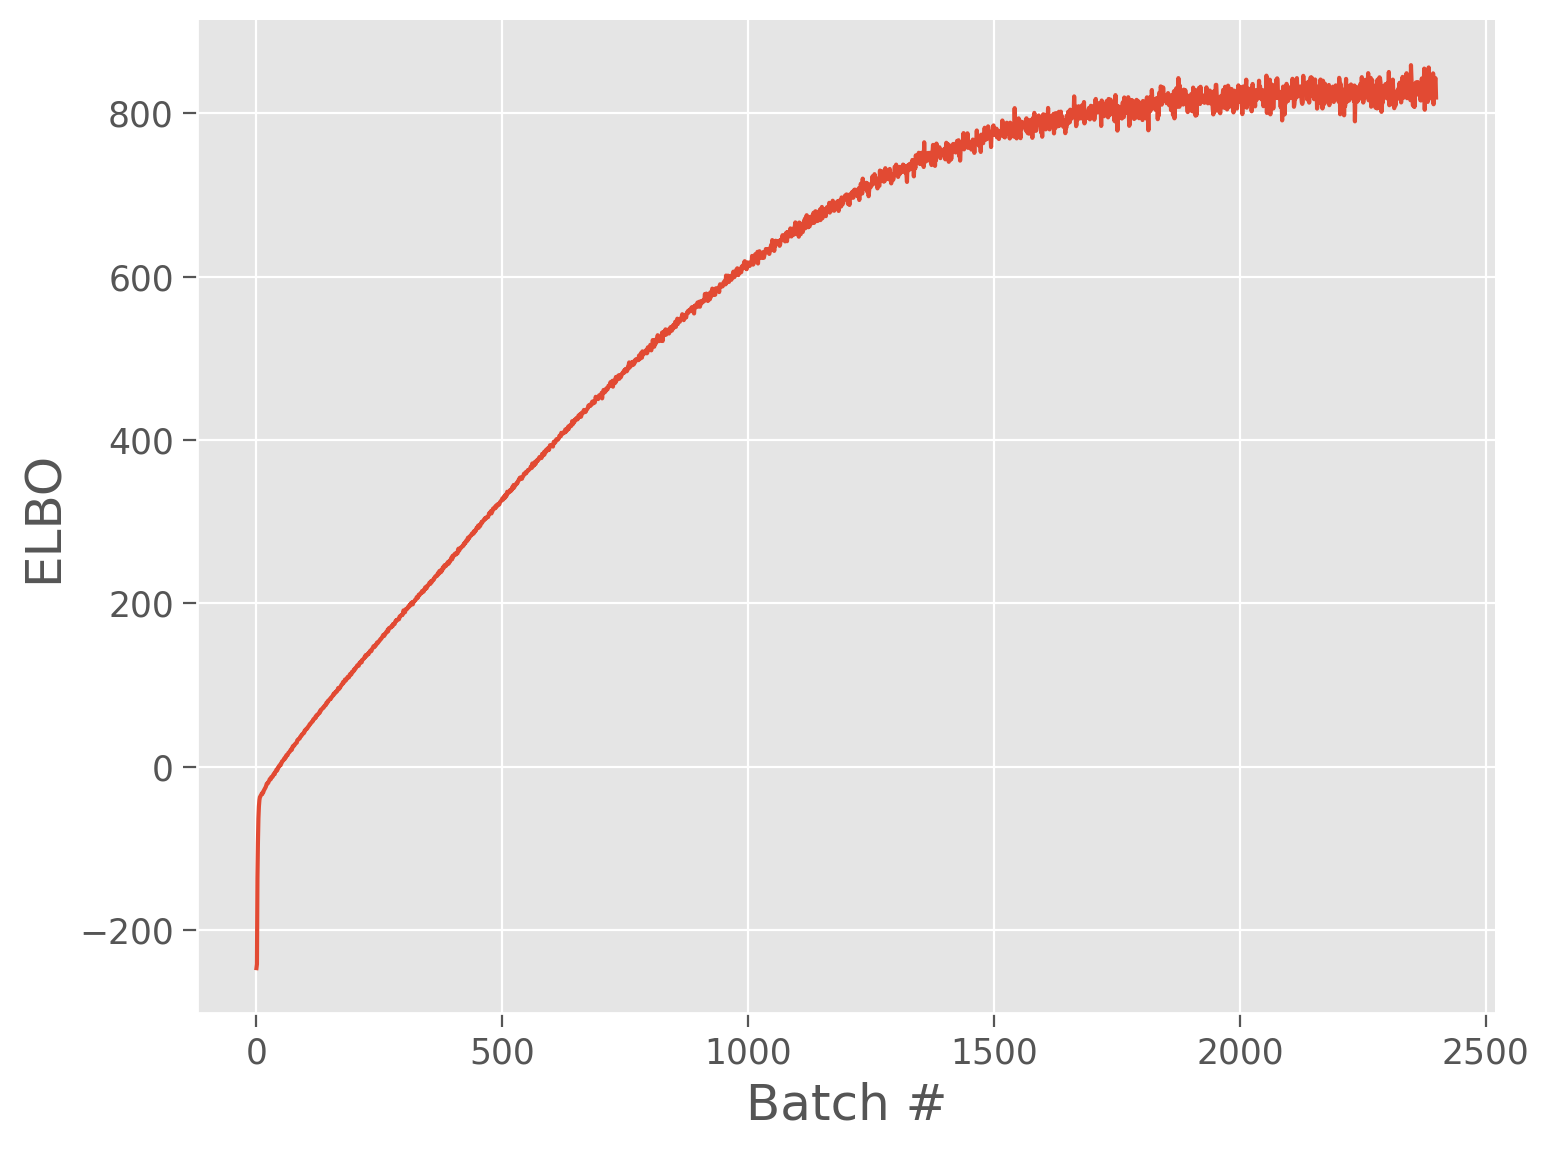

In [23]:

trained_conv_VarAE = ConvVAE(K=K_VAE)
elbo_vals = train_vae(trained_conv_VarAE, train_set, n_samples=10000)

print(f'Learned sigma_x is {torch.exp(trained_conv_VarAE.log_sig_x)}')

# the training curve of the evaluated ELBO loss function
# ELBO is the loss function used to train VAEs

plt.figure()
plt.plot(elbo_vals)
plt.xlabel('Batch #')
plt.ylabel('ELBO')
plt.show()


ELBO is the loss function used to train VAEs - note that we are maximizing ELBO (higher ELBO is better). We implement this in PyTorch code set up to minimize things by making the loss equal to negative ELBO.

Random seed 0 has been set.


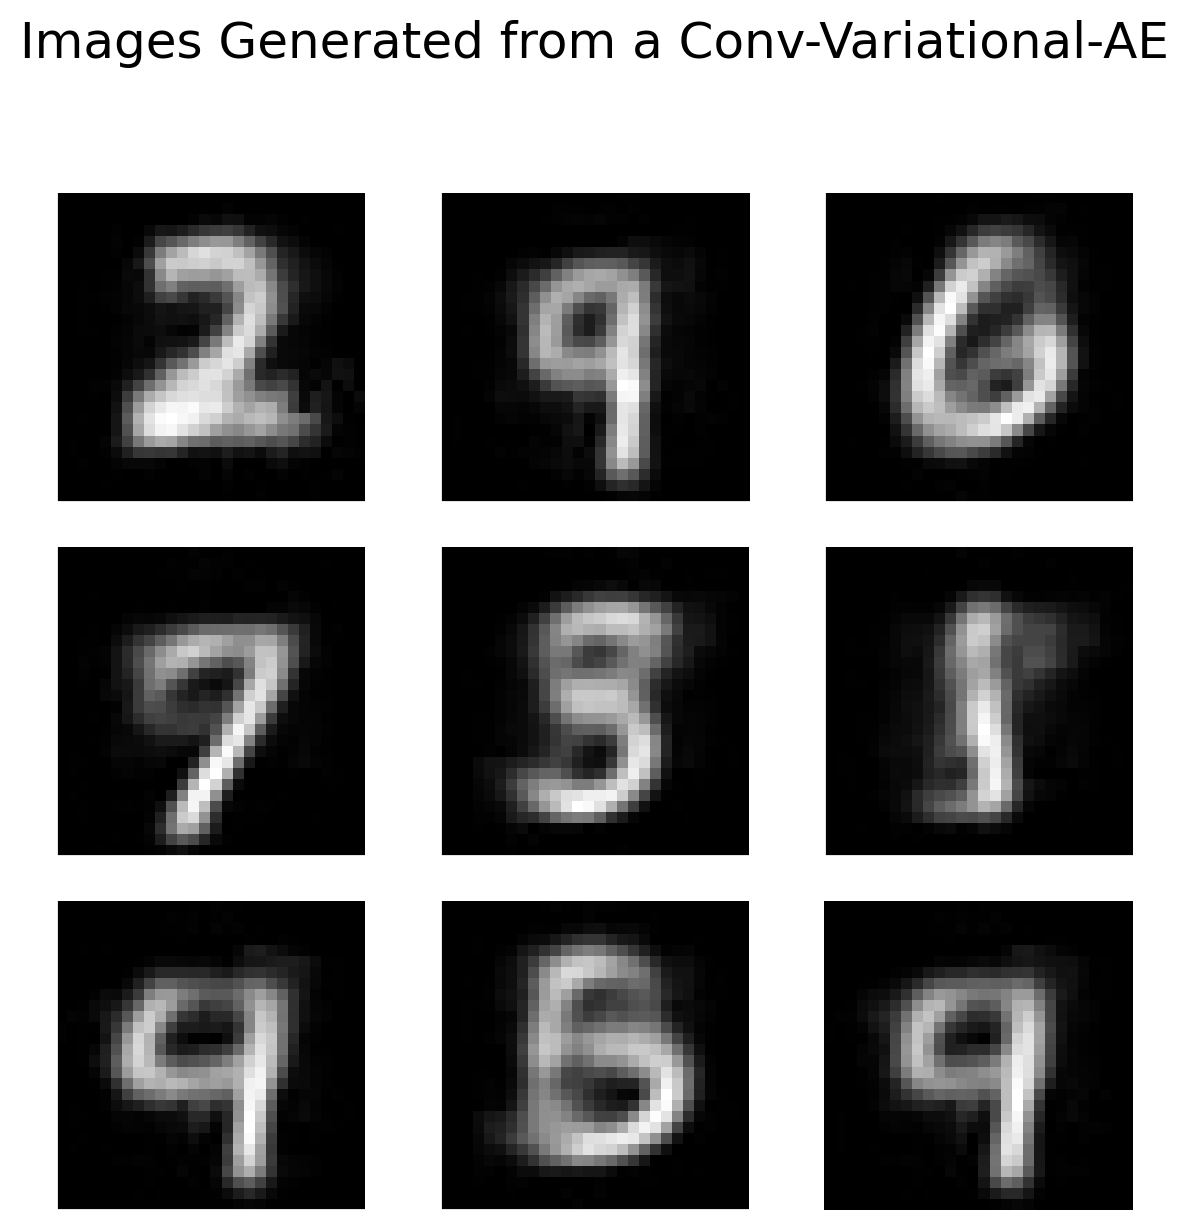

In [24]:

def generate_images(autoencoder, K, n_images=1):
  """
  Generate n_images 'new' images from the decoder part of the given
  autoencoder.

  Args:
    autoencoder: nn.module
      Autoencoder model
    K: int
      Bottleneck dimension
    n_images: int
      Number of images

  Returns:
    x: torch.tensor
      (n_images, channels, height, width) tensor of images
  """
  # Concatenate tuples to get (n_images, channels, height, width)
  output_shape = (n_images,) + data_shape
  with torch.no_grad():
    # Sample z from a unit gaussian, pass through autoencoder.decode()
    z = torch.randn(n_images, K)
    x = autoencoder.decode(z)

    return x.reshape(output_shape)



set_seed(seed=SEED)

images = generate_images(trained_conv_VarAE, K_VAE, n_images=9)
plot_images(images, plt_title='Images Generated from a Conv-Variational-AE')